# Laboratorium 2: Deep Learning w analizie motywów i struktur RNA

**Kierunek:** Bioinformatyka II stopień  
**Przedmiot:** Bioinformatyka strukturalna RNA  
**Moduł:** AI  
**Laboratoria:** 2  

**Wymagania**: Zmiana akceleratora sprzętowego na GPU!

Środowisko wykonawcze -> Zmień typ środowiska wykonawczego -> GPU T4

## Co dziś robimy
Na poprzednich zajęciach przeszliśmy cały pipeline ML/DL na danych tablicowych. Tu przechodzimy na **RNA** i dane sekwencyjne/strukturalne.

Dzisiaj:
1. **Szybki recap**: model operujący na sekwencjach o zmiennej długości (wejście Lxd, maski, padding).
2. **Wiązania kanoniczne** w strukturze drugorzędowej: A-U, G-C (wobble G-U i niekanoniczne pomijamy na razie).
3. Dwie rodziny modeli, które znajdują zastosowanie w predykcji struktury RNA:
   - **Transformery** (self-attention, dalekie zależności w sekwencji)
   - **Sieci grafowe (GNN)** (węzły = nukleotydy, krawędzie = relacje)
4. Następnie: one-hot, dot-bracket -> macierz kontaktów, padding/maskowanie, mini-trening.

> **Uwaga:** nierównowagę klas (szczególnie dotkliwą dla wiązań niekanonicznych) omówimy szerzej na kolejnych laboratoriach.





Struktura drugorzędowa RNA jako zadanie uczenia

Dla sekwencji długości **L** chcemy przewidzieć macierz kontaktów:

- **C ∈ {0,1}^{L×L}**
- C[i, j] = 1, jeśli i i j tworzą wiązanie (tu: **kanoniczne**)

To można ugryźć na kilka sposobów:
- **klasyfikacja par (i, j)**: bierzemy embeddingi pozycji i oraz j i uczymy klasyfikator
- **predykcja całej macierzy**: model generuje C jednocześnie (często z maską, ograniczeniami)
- **modelowanie grafowe**: uczymy reprezentacji węzłów i krawędzi w grafie RNA

Na tych labach pokazujemy minimalne, działające szkielety dla Transformerów i GNN, a potem pracujemy na przygotowanym zbiorze.



## Transformery

Transformer to (w uproszczeniu) stos bloków:
- **Embedding + (opcjonalnie) pozycje**
- **Multi-Head Self-Attention** (każda pozycja *patrzy* na inne)
- **MLP / Feed-Forward**
- Residual + LayerNorm

Dlaczego to pasuje do RNA?
- parowania zasad mogą być **dalekozasięgowe** (i <-> j), a attention łatwo „łączy” odległe pozycje

Poniżej minimalny kod: bierzemy sekwencję RNA -> embedding -> encoder -> robimy **skorowanie par (i, j)** przez prostą warstwę biliniową.



### Prosty schemat Transformera


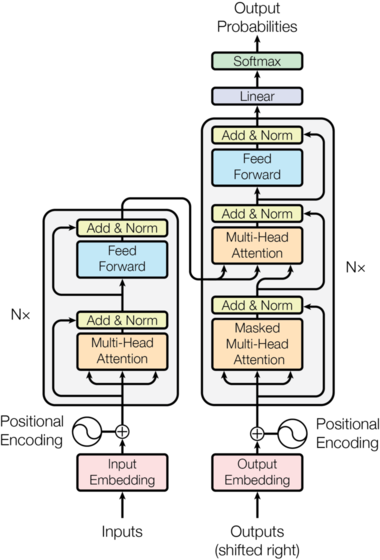

In [ ]:
from IPython.display import display
from PIL import Image
import os
os.listdir()

img = Image.open('images/transformer.png')
display(img)

In [ ]:

# Transformer encoder dla sekwencji RNA + predykcja par (i,j)
import torch
import torch.nn as nn
import numpy as np

# Mapowanie nukleotydów do indeksów - czy to dobry sposób?
vocab = {'A':0, 'C':1, 'G':2, 'U':3}
inv_vocab = {v:k for k,v in vocab.items()}

def encode_rna(seq: str):
    seq = seq.upper().replace("T","U")
    return torch.tensor([vocab[ch] for ch in seq], dtype=torch.long)

class PairwiseTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2):
        super().__init__()
        self.emb = nn.Embedding(4, d_model)
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.enc = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        # Bilinear: score(i,j) = h_i^T W h_j
        self.W = nn.Parameter(torch.randn(d_model, d_model) * 0.02)
        self.bias = nn.Parameter(torch.zeros(1))

    def forward(self, x):  # x: (B, L)
        h = self.emb(x)      # (B, L, d)
        h = self.enc(h)      # (B, L, d)
        # pairwise scores: (B, L, L)
        scores = torch.einsum('bld,df,bmf->blm', h, self.W, h) + self.bias
        return scores

# Demo na jednej sekwencji (bez treningu tylko żeby zobaczyć przepływ)
seq = "AUGGCUAUGCAU"
x = encode_rna(seq).unsqueeze(0)  # (1, L)
model = PairwiseTransformer()
with torch.no_grad():
    scores = model(x)  # (1, L, L)
print("seq:", seq)
print("scores shape:", scores.shape)


seq: AUGGCUAUGCAU
scores shape: torch.Size([1, 12, 12])



### Co z tym dalej?
W realnym treningu:
- trenujemy na macierzy kontaktów (transformacja z dot-bracket) i sekwencji / samej sekwencji,
- stosujemy dodatkowo Positional Encoding
- używamy np. `BCEWithLogitsLoss` na macierzy (maskując padding),
- często dodaje się ograniczenia (np. i nie może parować z wieloma j: problem multipletów) - ale to temat na później.



## GNN

W GNN budujemy graf:
- węzły: pozycje w sekwencji (nukleotydy)
- krawędzie: relacje, np. sąsiedztwo w sekwencji (i ↔ i+1), czasem też krawędzie „kandydackie”

Aktualizacja węzła to **message passing**:
- węzeł zbiera informacje od sąsiadów i aktualizuje embedding




### Prosty schemat GNN (message passing)

W GNN każdy węzeł (nukleotyd) aktualizuje swój wektor cech na podstawie sąsiadów.
Najczęściej robimy kilka kroków message passing (warstw), aby informacja „rozlała się” po grafie.




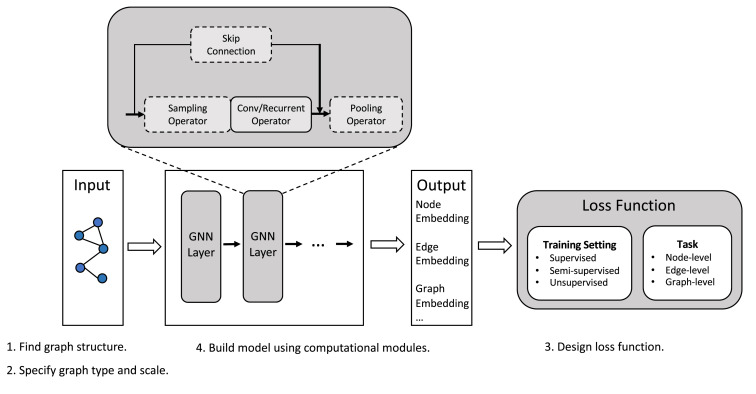

In [ ]:
img = Image.open('images/gnn.jpg')
display(img)

In [ ]:

# Minimalny przykład: prosta warstwa GCN (bez torch-geometric)
import torch
import torch.nn as nn
import numpy as np

# Mapowanie nukleotydów do indeksów (skopiowane z poprzedniej komórki)
vocab = {'A':0, 'C':1, 'G':2, 'U':3}
inv_vocab = {v:k for k,v in vocab.items()}

def make_chain_adjacency(L: int):
    A = np.zeros((L, L), dtype=np.float32)
    for i in range(L):
        if i-1 >= 0: A[i, i-1] = 1.0
        if i+1 < L: A[i, i+1] = 1.0
    # self-loops
    A += np.eye(L, dtype=np.float32)
    return torch.tensor(A)

def normalize_adj(A: torch.Tensor):
    # D^{-1/2} A D^{-1/2}
    deg = A.sum(dim=1)
    D_inv_sqrt = torch.diag(torch.pow(deg, -0.5))
    return D_inv_sqrt @ A @ D_inv_sqrt

class GCNLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.lin = nn.Linear(in_dim, out_dim, bias=False)
    def forward(self, X, A_norm):
        # X: (L, d)
        return torch.relu(A_norm @ self.lin(X))

class SimpleGCN(nn.Module):
    def __init__(self, d_in=4, d_hid=32, d_out=32, layers=2):
        super().__init__()
        self.layers = nn.ModuleList()
        dims = [d_in] + [d_hid]*(layers-1) + [d_out]
        for i in range(layers):
            self.layers.append(GCNLayer(dims[i], dims[i+1]))
    def forward(self, X, A_norm):
        h = X
        for layer in self.layers:
            h = layer(h, A_norm)
        return h  # (L, d_out)

# Demo: sekwencja -> one-hot -> GCN -> embeddingi pozycji
seq = "AUGGCUAUGCAU".replace("T","U")
L = len(seq)
onehot = torch.zeros(L, 4)
for i,ch in enumerate(seq):
    onehot[i, vocab[ch]] = 1.0

A = make_chain_adjacency(L)
A_norm = normalize_adj(A)

gcn = SimpleGCN(d_in=4, d_hid=16, d_out=16, layers=2)
with torch.no_grad():
    h = gcn(onehot, A_norm)

print("seq:", seq)
print("node embeddings shape:", h.shape)  # (L, d)


seq: AUGGCUAUGCAU
node embeddings shape: torch.Size([12, 16])



### Jak z GNN zrobić predykcję wiązań?
Analogicznie jak w Transformerze:
- po GNN mamy embedding h_i dla pozycji i
- dla pary (i,j) robimy score(i,j) np. przez iloczyn skalarny / bilinear / małe MLP na [h_i, h_j, |h_i-h_j|]
- uczymy na macierzy kontaktów

Na kolejnych labach zobaczymy, że to podejście naturalnie rozszerza się na trudniejsze typy wiązań.


## 0. Przygotowanie środowiska
Instalujemy niezbędne biblioteki. Pobieramy dane treningowe.

In [ ]:
# @title
!apt-get install -y cd-hit > /dev/null 2>&1
from numpy.random.mtrand import sample
from torch.cuda import is_available
!pip install -q datasets pandas scikit-learn torch torchvision torchaudio matplotlib tqdm biopython

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, Dataset

# Ustawienie ziarna losowości dla powtarzalności wyników
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Wykrywanie dostępnego urządzenia (CPU lub GPU)
if not torch.cuda.is_available():
    raise RuntimeError("GPU (CUDA) jest wymagane, ale nie jest dostępne. Sprawdź ustawienia środowiska Środowisko wykonawcze -> Zmień typ środowiska wykonawczego -> GPU T4")

device = torch.device("cuda")
dataset2D = load_dataset("multimolecule/bprna", split='train')
sample2D = next(iter(dataset2D))

#dataset3D
#https://github.com/marcellszi/rna3db


## 1. Reprezentacja sekwencji RNA: One-Hot Encoding

 Sekwencje kwasów nukleinowych są pierwotnie reprezentowane jako ciągi symboli kategorycznych (A, C, G, U). Algorytmy uczenia głębokiego wymagają jednak wejściowej reprezentacji numerycznej. Kodowanie typu One-Hot (jedynkowe) polega na mapowaniu każdego nukleotydu na ortogonalny wektor binarny o wymiarze N=4. Zapewnia to równą odległość między reprezentacjami wszystkich zasad, zapobiegając błędnemu przypisaniu hierarchii numerycznej przez sieć neuronową.

In [ ]:
from Bio.Seq import Seq

def rna_to_one_hot(sequence_str):
    seq = Seq(sequence_str.upper().replace("T", "U"))
    mapping = {'A': 0, 'C': 1, 'G': 2, 'U': 3}
    one_hot = torch.zeros(len(seq), 4)
    for i, base in enumerate(seq):
        if base in mapping:
            one_hot[i, mapping[base]] = 1.0
    return one_hot

print(sample2D['sequence'][:10])
print(rna_to_one_hot(sample2D['sequence'][:10]))

ACACAUGCAA
tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [0., 0., 0., 1.],
        [0., 0., 1., 0.],
        [0., 1., 0., 0.],
        [1., 0., 0., 0.],
        [1., 0., 0., 0.]])


## 2. Mapy kontaktów: dot-bracket -> macierz 2D

Struktura drugorzędowa RNA, definiowana przez zbiór kanonicznych parowań zasad, może zostać sformalizowana jako macierz sąsiedztwa (mapa kontaktów). Taka reprezentacja pozwala na aplikację splotowych sieci neuronowych (CNN), które traktują mapę kontaktów jako dwuwymiarowy obraz topologii cząsteczki.


Sekwencja: CCGCAUCCCGUCUGAUCUGC
Dot-bracket: ..(((............)))




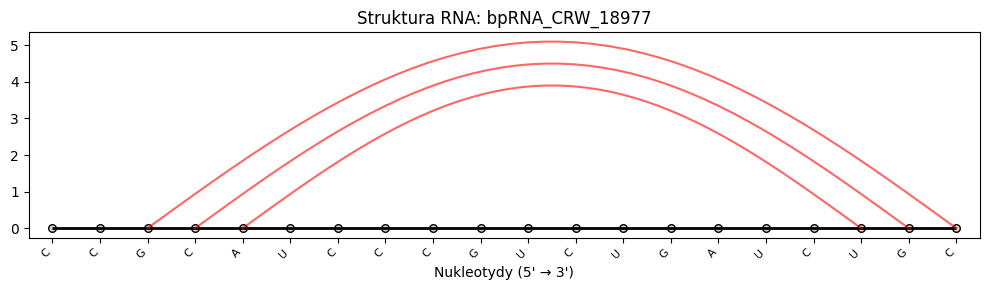


Macierz kontaktów 20x20:
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0

In [ ]:

# === 1. Załadowanie danych i znalezienie krótkiej sekwencji z interakcjami ===

short_sample = None
for item in dataset2D:
    seq = item['sequence']
    struct = item['secondary_structure']
    if len(seq) <= 20 and '(' in struct:
        short_sample = item
        break
if short_sample is None:
    short_sample = dataset2D[0]

# === Parser ===
def dbn_to_matrix(dot_bracket):
    L = len(dot_bracket)
    matrix = torch.zeros((L, L))
    stack = []
    for i, char in enumerate(dot_bracket):
        if char == '(':
            stack.append(i)
        elif char == ')':
            if stack:
                j = stack.pop()
                matrix[i, j] = 1.0
                matrix[j, i] = 1.0
    return matrix

seq = short_sample['sequence']
struct = short_sample['secondary_structure']
contact = dbn_to_matrix(struct).numpy()
L = len(seq)

print(f"\nSekwencja: {seq}")
print(f"Dot-bracket: {struct}")
print("\n")

plt.figure(figsize=(10, 3))
plt.hlines(0, 0, L-1, colors='black', linewidth=2)
plt.scatter(range(L), [0]*L, s=30, c='lightgray', edgecolors='black')

pairs = [(i, j) for i in range(L) for j in range(i+1, L) if contact[i, j] == 1]
for i, j in pairs:
    height = 0.3 * (j - i)
    t = np.linspace(0, 1, 50)
    plt.plot(i + (j-i)*t, height * np.sin(np.pi * t), 'r-', alpha=0.6, linewidth=1.5)

plt.xticks(range(L), list(seq), rotation=45, ha='right', fontsize=8)
plt.xlim(-0.5, L-0.5)
plt.xlabel("Nukleotydy (5' → 3')")
plt.title(f"Struktura RNA: {short_sample['id']}")
plt.tight_layout()
plt.show()

print(f"\nMacierz kontaktów {L}x{L}:")
for i in range(L):
  row = [int(contact[i, j]) for j in range(L)]
  row_str = "[" + ", ".join(str(x) for x in row) + "]"
  print(row_str)

## 3. Obsługa zmiennej długości sekwencji: Padding i Maskowanie

Architektury sieci neuronowych przetwarzające dane w paczkach (batches) wymagają wejściowych tensorów o stałych wymiarach. W bioinformatyce RNA, gdzie cząsteczki mają różną liczbę nukleotydów, stosuje się padding (dopełnianie zerami do długości najdłuższej sekwencji w paczce). Aby model nie interpretował zer jako realnych danych, wprowadza się maskowanie. Maska to tensor binarny informujący funkcję straty i warstwy sieci (np. atencję), które pozycje są rzeczywistymi nukleotydami, a które jedynie technicznym wypełnieniem.

In [ ]:
class RNAPaddedDataset(Dataset):
    def __init__(self, hf_dataset, max_len=120):
        self.data = list(hf_dataset.take(100))
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq_raw = self.data[idx]['sequence'][:self.max_len]
        dbn_raw = self.data[idx]['secondary_structure'][:self.max_len]
        curr_l = len(seq_raw)

        # 1. Generowanie reprezentacji bazowych
        x = rna_to_one_hot(seq_raw)
        y = dbn_to_matrix(dbn_raw)

        # 2. PADDING
        x_padded = torch.zeros((self.max_len, 4))
        x_padded[:curr_l, :] = x

        y_padded = torch.zeros((self.max_len, self.max_len))
        y_padded[:curr_l, :curr_l] = y

        # 3. MASKA
        mask = torch.zeros(self.max_len)
        mask[:curr_l] = 1.0

        return x_padded, y_padded, mask

padded_ds = RNAPaddedDataset(dataset2D)
sample_x, sample_y, sample_mask = padded_ds[0]

print(f"Kształt X po paddingu: {sample_x.shape}")
print(f"Kształt Y po paddingu: {sample_y.shape}")
print(f"Suma maski (faktyczna długość RNA): {sample_mask.sum().item()}")

Kształt X po paddingu: torch.Size([120, 4])
Kształt Y po paddingu: torch.Size([120, 120])
Suma maski (faktyczna długość RNA): 120.0


## 4. Klastrowanie biologiczne (Zapobieganie Data Leakage)
Losowy podział danych w bioinformatyce strukturalnej jest błędem metodologicznym, jeśli ewolucyjnie spokrewnione sekwencje trafią do obu zbiorów. Prowadzi to do wycieku danych, gdzie model "zapamiętuje" znane motywy, a nie uczy się ogólnych zasad. Należy stosować podział oparty na klastrowaniu sekwencji według podobieństwa (np. 80% identyczności), co odpowiada rodzinom RNA.

W zbiorze multimolecule/bprna brak gotowych etykiet rodzin, dlatego sami tworzymy klastry za pomocą narzędzia CD-HIT. Poniższy kod:

* Wybiera podzbiór danych (np. 5000 sekwencji), aby klastrowanie było szybkie

* Uruchamia CD-HIT z progiem podobieństwa 80%

* Dzieli całe klastry na zbiory treningowy (70%), walidacyjny (15%) i testowy (15%)

Dlaczego to ważne?
Nawet jeśli podział na poziomie klastrów jest poprawny metodologicznie, może się zdarzyć, że liczba klastrów jest mała i ich rozmiary bardzo zróżnicowane. W efekcie walidacja i test mogą zawierać niewiele przykładów, co utrudnia rzetelną ocenę modelu. Dodanie debugów pozwala na szybką weryfikację i ewentualną korektę parametrów (np. zmniejszenie progu podobieństwa, zwiększenie podzbioru).

Liczba sekwencji w podzbiorze: 19000
Zapisano sekwencje do bprna_sequences.fasta
Klastrowanie zakończone.
Liczba utworzonych klastrów: 264
Łączna liczba sekwencji w klastrach: 19000
Wszystkie sekwencje poprawnie zmapowane.

--- Statystyki klastrów ---
Min: 1, Max: 4542, Średnia: 72.0, Mediana: 2.0
Rozkład rozmiarów (pierwsze 20):
  Klaster 0: 520 sekwencji
  Klaster 1: 1648 sekwencji
  Klaster 2: 1553 sekwencji
  Klaster 3: 275 sekwencji
  Klaster 4: 4542 sekwencji
  Klaster 5: 10 sekwencji
  Klaster 6: 20 sekwencji
  Klaster 7: 26 sekwencji
  Klaster 8: 299 sekwencji
  Klaster 9: 2694 sekwencji
  Klaster 10: 420 sekwencji
  Klaster 11: 323 sekwencji
  Klaster 12: 1 sekwencji
  Klaster 13: 311 sekwencji
  Klaster 14: 2141 sekwencji
  Klaster 15: 1064 sekwencji
  Klaster 16: 52 sekwencji
  Klaster 17: 8 sekwencji
  Klaster 18: 12 sekwencji
  Klaster 19: 13 sekwencji


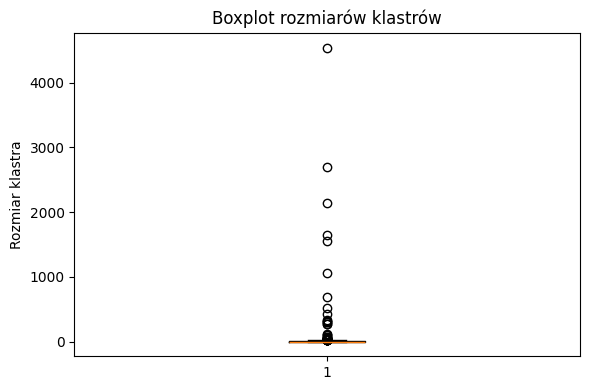


Podział klastrów:
  Train: 184 klastrów
  Val:   40 klastrów
  Test:  40 klastrów

Liczba przykładów w zbiorach:
  Train: 14909
  Val:   2348
  Test:  1743

Sumaryczne rozmiary klastrów w zbiorach:
  Train: łącznie 14909 sekwencji w 184 klastrach
  Val:   łącznie 2348 sekwencji w 40 klastrach
  Test:  łącznie 1743 sekwencji w 40 klastrach

Gotowe! Zbiory zostały podzielone z zachowaniem integralności klastrów.


In [ ]:

# 1. Wybór podzbioru danych
SUBSET_SIZE = 19000  # możesz zmienić na mniejszy (np. 5000) dla szybszego testu
subset = dataset2D.select(range(min(SUBSET_SIZE, len(dataset2D))))
print(f"Liczba sekwencji w podzbiorze: {len(subset)}")

# 2. Zapis do pliku FASTA
fasta_file = "bprna_sequences.fasta"
with open(fasta_file, "w") as f:
    for i, ex in enumerate(subset):
        f.write(f">seq_{i}\n{ex['sequence']}\n")
print(f"Zapisano sekwencje do {fasta_file}")

# 3. Uruchomienie CD-HIT (próg 80% podobieństwa)
!cd-hit -i {fasta_file} -o clusters -c 0.8 -n 5 -d 0 -M 0 -T 0 > /dev/null 2>&1
print("Klastrowanie zakończone.")

# 4. Parsowanie pliku .clstr (niezawodne regexem)
def parse_clusters(clstr_file):
    clusters = []
    current = []
    with open(clstr_file, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">Cluster"):
                if current:
                    clusters.append(current)
                current = []
            else:
                # Wyłapuje >seq_<liczba> nawet jeśli po niej są kropki/gwiazdki
                match = re.search(r'>seq_(\d+)', line)
                if match:
                    seq_id = f"seq_{match.group(1)}"
                    current.append(seq_id)
        if current:
            clusters.append(current)
    return clusters

clusters = parse_clusters("clusters.clstr")
print(f"Liczba utworzonych klastrów: {len(clusters)}")

# 5. Walidacja zgodności liczby sekwencji
total_in_clusters = sum(len(c) for c in clusters)
print(f"Łączna liczba sekwencji w klastrach: {total_in_clusters}")
if total_in_clusters != len(subset):
    print(f"Niezgodność! W klastrach jest {total_in_clusters} sekwencji, a subset ma {len(subset)}.")

# 6. Mapowanie seq_id -> klaster
seq_to_cluster = {}
for cid, seq_list in enumerate(clusters):
    for sid in seq_list:
        seq_to_cluster[sid] = cid

# Sprawdzenie, czy wszystkie indeksy są obecne
missing = [i for i in range(len(subset)) if f"seq_{i}" not in seq_to_cluster]
if missing:
    print(f"Brakuje {len(missing)} sekwencji w mapowaniu, np. {missing[:10]}")
    # Można by je pominąć, ale lepiej wrócić do poprawy parsowania.
    # Na wszelki wypadek usuwamy je z subsetu (ale to ostateczność).
    print("UWAGA: Brakujące sekwencje zostaną pominięte w dalszych krokach.")
    valid_indices = [i for i in range(len(subset)) if f"seq_{i}" in seq_to_cluster]
    subset = subset.select(valid_indices)
    print(f"Nowy rozmiar subsetu (po usunięciu brakujących): {len(subset)}")
else:
    print("Wszystkie sekwencje poprawnie zmapowane.")

# 7. Statystyki klastrów
sizes = [len(c) for c in clusters]
print(f"\n--- Statystyki klastrów ---")
print(f"Min: {min(sizes)}, Max: {max(sizes)}, Średnia: {np.mean(sizes):.1f}, Mediana: {np.median(sizes)}")
print("Rozkład rozmiarów (pierwsze 20):")
for i, size in enumerate(sizes[:20]):
    print(f"  Klaster {i}: {size} sekwencji")

# Boxplot rozmiarów klastrów
plt.figure(figsize=(6, 4))
plt.boxplot(sizes)
plt.ylabel("Rozmiar klastra")
plt.title("Boxplot rozmiarów klastrów")
plt.tight_layout()
plt.show()

# 8. Podział klastrów na zbiory (70% train, 15% val, 15% test)
unique_clusters = list(range(len(clusters)))
random.Random(SEED).shuffle(unique_clusters)

n = len(unique_clusters)
train_clusters = set(unique_clusters[:int(0.7*n)])
val_clusters   = set(unique_clusters[int(0.7*n):int(0.85*n)])
test_clusters  = set(unique_clusters[int(0.85*n):])

print(f"\nPodział klastrów:")
print(f"  Train: {len(train_clusters)} klastrów")
print(f"  Val:   {len(val_clusters)} klastrów")
print(f"  Test:  {len(test_clusters)} klastrów")

# 9. Tworzenie list indeksów według przynależności klastrów
train_idx, val_idx, test_idx = [], [], []
for idx in range(len(subset)):
    cid = seq_to_cluster[f"seq_{idx}"]
    if cid in train_clusters:
        train_idx.append(idx)
    elif cid in val_clusters:
        val_idx.append(idx)
    else:
        test_idx.append(idx)

print(f"\nLiczba przykładów w zbiorach:")
print(f"  Train: {len(train_idx)}")
print(f"  Val:   {len(val_idx)}")
print(f"  Test:  {len(test_idx)}")

# 10. Podsumowanie rozmiarów klastrów w zbiorach
train_sizes = [sizes[c] for c in train_clusters]
val_sizes   = [sizes[c] for c in val_clusters]
test_sizes  = [sizes[c] for c in test_clusters]

print(f"\nSumaryczne rozmiary klastrów w zbiorach:")
print(f"  Train: łącznie {sum(train_sizes)} sekwencji w {len(train_clusters)} klastrach")
print(f"  Val:   łącznie {sum(val_sizes)} sekwencji w {len(val_clusters)} klastrach")
print(f"  Test:  łącznie {sum(test_sizes)} sekwencji w {len(test_clusters)} klastrach")

# 11. Utworzenie finalnych subsetów Dataset
train_dataset = subset.select(train_idx)
val_dataset   = subset.select(val_idx)
test_dataset  = subset.select(test_idx)
7

print("\nGotowe! Zbiory zostały podzielone z zachowaniem integralności klastrów.")

## 5. Architektury splotowe (2D CNN) do detekcji motywów

Warstwy splotowe wyodrębniają lokalne cechy strukturalne (np. helisy, pętle) poprzez analizę korelacji przestrzennych w macierzy sąsiedztwa

In [ ]:
# Najpierw musimy utworzyć DataLoader z użyciem RNAPaddedDataset.
# W sekcji 3 zdefiniowaliśmy klasę RNAPaddedDataset, która zamienia surowe dane na tensory (one-hot, macierz kontaktów, maska).
# Tutaj wykorzystamy nasze zbiory z sekcji 4 (train_dataset, val_dataset, test_dataset) – to są obiekty Dataset Hugging Face.
# Ale RNAPaddedDataset przyjmuje obiekt Hugging Face Dataset i zamienia go na tensory.
# Dlatego tworzymy instancje RNAPaddedDataset dla każdego zbioru.

from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

# Parametry
MAX_LEN = 120
BATCH_SIZE = 4

# Tworzymy przetworzone dataset'y
train_processed = RNAPaddedDataset(train_dataset, max_len=MAX_LEN)
val_processed = RNAPaddedDataset(val_dataset, max_len=MAX_LEN)
test_processed = RNAPaddedDataset(test_dataset, max_len=MAX_LEN)

# Tworzymy loadery
train_loader = DataLoader(train_processed, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_processed, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)


class PairwiseCNN(nn.Module):
    """
    2D CNN, który na podstawie one-hot sekwencji RNA przewiduje macierz kontaktów.
    Wejście: (B, L, 4) – kodowanie one-hot
    Wyjście: (B, L, L) – logity (przed sigmoid)
    """
    def __init__(self, hidden_channels=32, kernel_size=3):
        super().__init__()
        # Warstwy splotowe 2D – na wejściu 16 cech (4x4 z iloczynu zewnętrznego)
        self.conv1 = nn.Conv2d(16, hidden_channels, kernel_size, padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm2d(hidden_channels)
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm2d(hidden_channels)
        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (B, L, 4)
        # Obliczamy cechy par (i,j) jako iloczyn zewnętrzny wektorów one-hot
        pair = torch.einsum('blf,bmg->blmfg', x, x)   # (B, L, L, 4, 4)
        B, L = pair.shape[:2]
        pair = pair.reshape(B, L, L, 16)              # (B, L, L, 16)
        pair = pair.permute(0, 3, 1, 2)               # (B, 16, L, L)

        out = self.relu(self.bn1(self.conv1(pair)))
        out = self.relu(self.bn2(self.conv2(out)))
        logits = self.final_conv(out).squeeze(1)      # (B, L, L)

        # Wymuszenie symetrii macierzy kontaktów
        logits = (logits + logits.transpose(1, 2)) / 2

        return logits

### DO SEKCJI 6

def weighted_bce_loss(logits, targets, mask=None, pos_weight=None):
    """
    Oblicza ważoną stratę Binary Cross Entropy dla macierzy kontaktów.

    Argumenty:
        logits (torch.Tensor): (B, L, L) – surowe wyniki modelu (przed sigmoid)
        targets (torch.Tensor): (B, L, L) – rzeczywiste etykiety (0 lub 1)
        mask (torch.Tensor, opcjonalnie): (B, L) – maska sekwencji (1 dla rzeczywistych pozycji)
        pos_weight (float, opcjonalnie): waga dla klasy pozytywnej.
                                         Jeśli None, liczona automatycznie z bieżącego batcha.

    Zwraca:
        scalar – średnia strata po uwzględnieniu maski.
    """
    if mask is not None:
        # Maska par (i, j) – tylko tam, gdzie obie pozycje są rzeczywiste
        mm = mask.unsqueeze(2) * mask.unsqueeze(1)  # (B, L, L)
    else:
        mm = torch.ones_like(targets)

    # Jeśli nie podano wagi, liczymy ją z bieżącego batcha (do debug/demo)
    if pos_weight is None:
        pos = (targets * mm).sum().item()   # liczba kontaktów w batchu (ważona maską)
        neg = ((1 - targets) * mm).sum().item()  # liczba braków kontaktu
        pos_weight = max(neg / (pos + 1e-8), 1.0)

    pos_weight_tensor = torch.as_tensor(pos_weight, device=logits.device, dtype=logits.dtype)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor, reduction='none')
    loss_map = loss_fn(logits, targets)

    # Zastosowanie maski i uśrednienie
    loss_map = loss_map * mm
    return loss_map.sum() / (mm.sum() + 1e-8)


def compute_pos_weight(loader, device):
    """
    Liczy globalny pos_weight na podstawie całego zbioru treningowego.
    """
    total_pos = 0.0
    total_neg = 0.0

    for x_batch, y_batch, mask_batch in loader:
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        mm = mask_batch.unsqueeze(2) * mask_batch.unsqueeze(1)

        total_pos += (y_batch * mm).sum().item()
        total_neg += ((1 - y_batch) * mm).sum().item()

    return max(total_neg / (total_pos + 1e-8), 1.0)

# Liczymy globalne pos_weight
pos_weight = np.sqrt(compute_pos_weight(train_loader, device))
print(f"Globalne pos_weight: {pos_weight:.2f}")

# Inicjalizacja modelu, optymalizatora i schedulera
cnn_model = PairwiseCNN(hidden_channels=32).to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

# Trening przez kilka epok (demonstracja)
num_epochs = 10
train_losses, val_losses = [], []

for epoch in range(1, num_epochs + 1):
    cnn_model.train()
    total_loss = 0.0

    for x_batch, y_batch, mask_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        optimizer.zero_grad()
        logits = cnn_model(x_batch)

        # Używamy globalnie policzonej wagi
        loss = weighted_bce_loss(logits, y_batch, mask_batch, pos_weight=pos_weight)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Walidacja
    cnn_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch, mask_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            logits = cnn_model(x_batch)
            loss = weighted_bce_loss(logits, y_batch, mask_batch, pos_weight=pos_weight)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    print(f"Epoka {epoch:2d} | Strata treningowa: {avg_train_loss:.4f} | Strata walidacyjna: {avg_val_loss:.4f}")

print("Trening zakończony.")

Globalne pos_weight: 20.70
Epoka  1 | Strata treningowa: 0.5821 | Strata walidacyjna: 0.5928
Epoka  2 | Strata treningowa: 0.4136 | Strata walidacyjna: 0.4008
Epoka  3 | Strata treningowa: 0.3049 | Strata walidacyjna: 0.3040
Epoka  4 | Strata treningowa: 0.2339 | Strata walidacyjna: 0.2527
Epoka  5 | Strata treningowa: 0.1846 | Strata walidacyjna: 0.2124
Epoka  6 | Strata treningowa: 0.1496 | Strata walidacyjna: 0.1939
Epoka  7 | Strata treningowa: 0.1239 | Strata walidacyjna: 0.1820
Epoka  8 | Strata treningowa: 0.1050 | Strata walidacyjna: 0.1694
Epoka  9 | Strata treningowa: 0.0898 | Strata walidacyjna: 0.1666
Epoka 10 | Strata treningowa: 0.0783 | Strata walidacyjna: 0.1620
Trening zakończony.


## 6. Funkcje straty dla rzadkich interakcji (Weighted BCE)
Macierze parowań są "rzadkie" (klasa 0 dominuje). Stosujemy Weighted Cross-Entropy, aby nadać wyższą wagę rzadkim, ale kluczowym biologicznie parowaniom zasad

In [ ]:
# Pobieramy jeden batch, żeby sprawdzić, co zwraca
sample_batch = next(iter(train_loader))
print(f"Batch zawiera {len(sample_batch)} elementów.")
print(f"Typy elementów: {[type(x) for x in sample_batch]}")
print(f"Kształt x: {sample_batch[0].shape} (powinien być [batch_size, max_len, 4])")
print(f"Kształt y: {sample_batch[1].shape} (powinien być [batch_size, max_len, max_len])")
print(f"Kształt mask: {sample_batch[2].shape} (powinien być [batch_size, max_len])")

# Rozpakowujemy
x_batch, y_batch, mask_batch = sample_batch

# --- Przykład użycia na naszym batchu ---
print("\n--- Test ważonej straty na przykładowym batchu ---")

# Symulujemy logity (np. z modelu) – na razie losowe
dummy_logits = torch.randn_like(y_batch)

# Obliczamy stratę z globalną wagą
loss = weighted_bce_loss(dummy_logits, y_batch, mask_batch, pos_weight=pos_weight)
print(f"Strata (z globalnym pos_weight): {loss.item():.4f}")

# Obliczamy stratę z ręcznie zadaną wagą (np. 10.0)
loss_fixed = weighted_bce_loss(dummy_logits, y_batch, mask_batch, pos_weight=10.0)
print(f"Strata (z wagą 10.0): {loss_fixed.item():.4f}")

# Porównanie ze zwykłą stratą (bez ważenia) – czyli pos_weight=1.0
loss_unweighted = weighted_bce_loss(dummy_logits, y_batch, mask_batch, pos_weight=1.0)
print(f"Strata (bez ważenia, pos_weight=1.0): {loss_unweighted.item():.4f}")

Batch zawiera 3 elementów.
Typy elementów: [<class 'torch.Tensor'>, <class 'torch.Tensor'>, <class 'torch.Tensor'>]
Kształt x: torch.Size([4, 120, 4]) (powinien być [batch_size, max_len, 4])
Kształt y: torch.Size([4, 120, 120]) (powinien być [batch_size, max_len, max_len])
Kształt mask: torch.Size([4, 120]) (powinien być [batch_size, max_len])

--- Test ważonej straty na przykładowym batchu ---
Strata (z globalnym pos_weight): 0.8449
Strata (z wagą 10.0): 0.8249
Strata (bez ważenia, pos_weight=1.0): 0.8081


## 7. Interpretowalność modelu: Mapy aktywacji i ważności

Monitorowanie krzywych uczenia pozwala wykryć overfitting na wczesnym etapie. W bioinformatyce kluczowe jest sprawdzenie, czy model nie zapamiętuje szumu w strukturach referencyjnych

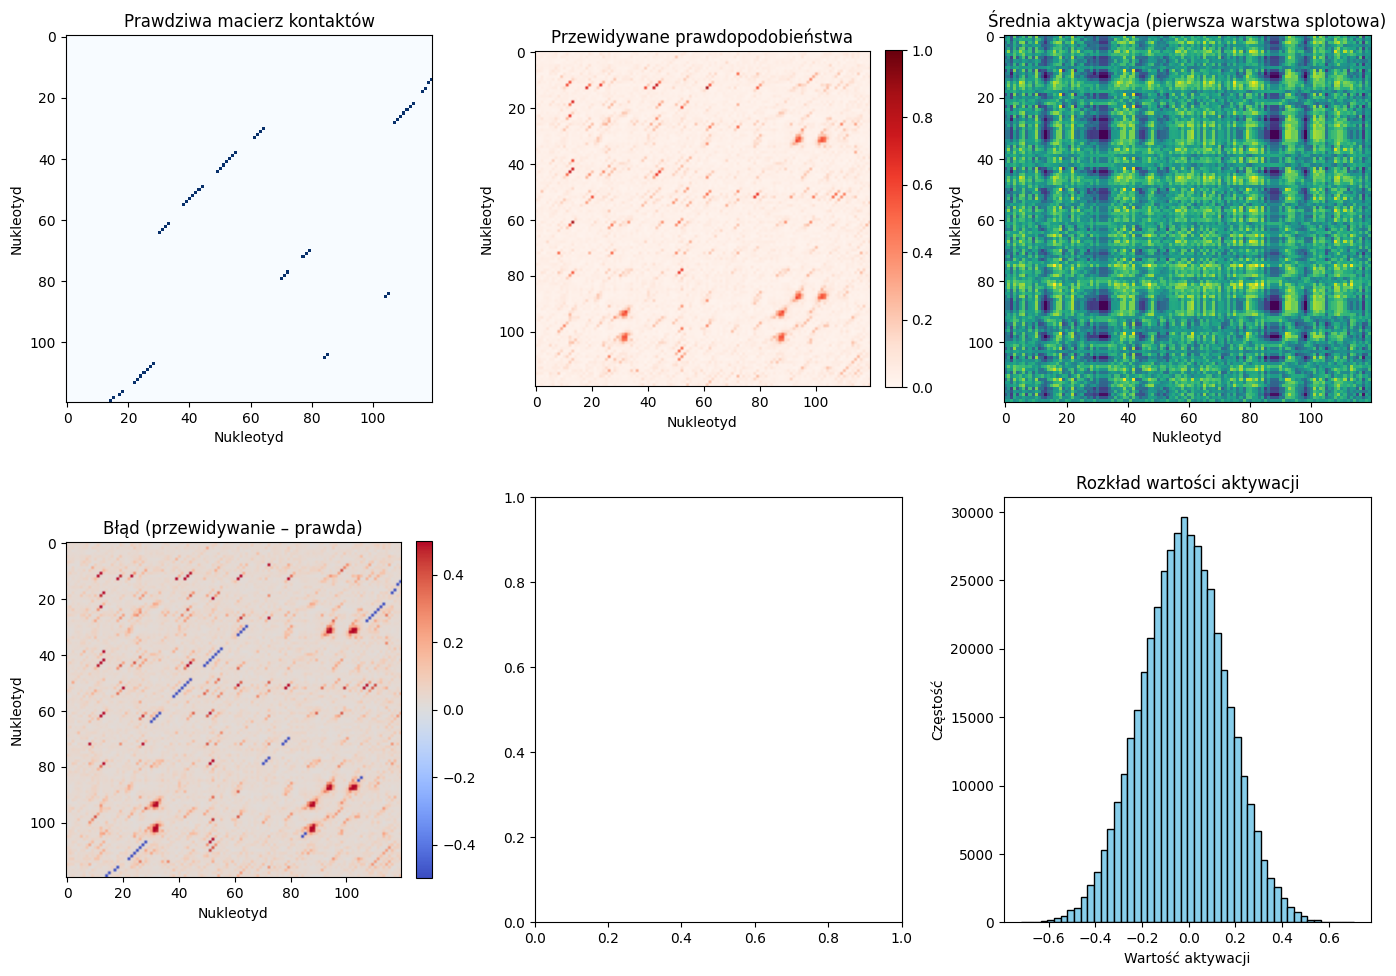

Mapy aktywacji pokazują, które obszary macierzy kontaktów są najbardziej istotne dla modelu.


In [ ]:
# ========== Interpretowalność modelu ==========
import matplotlib.pyplot as plt
import numpy as np

# Pobieramy jedną próbkę z testu
x_sample, y_sample, mask_sample = next(iter(test_loader))
x_sample = x_sample[0:1].to(device)   # (1, L, 4)
y_sample = y_sample[0]                # (L, L)
mask_sample = mask_sample[0]          # (L,)
L_actual = int(mask_sample.sum().item())

# Hook do przechwycenia aktywacji pierwszej warstwy splotowej
activations = []
def hook_fn(module, input, output):
    activations.append(output.detach())

hook = cnn_model.conv1.register_forward_hook(hook_fn)

# Forward pass
cnn_model.eval()
with torch.no_grad():
    logits = cnn_model(x_sample)
    probs = torch.sigmoid(logits)

hook.remove()
act = activations[0][0]  # (hidden_channels, L, L)

# Przycinamy do rzeczywistej długości
true_contact = y_sample[:L_actual, :L_actual].cpu().numpy()
pred_prob = probs[0, :L_actual, :L_actual].cpu().numpy()
mean_act = act.mean(dim=0)[:L_actual, :L_actual].cpu().numpy()
error = pred_prob - true_contact

# Wybieramy kanał o największej wariancji aktywacji
variances = act.view(act.size(0), -1).var(dim=1)
max_var_idx = variances.argmax().item()
max_var_act = act[max_var_idx, :L_actual, :L_actual].cpu().numpy()

# Rysujemy wizualizacje
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# Macierz kontaktów prawdziwa
axes[0,0].imshow(true_contact, cmap='Blues', interpolation='nearest')
axes[0,0].set_title('Prawdziwa macierz kontaktów')
axes[0,0].set_xlabel('Nukleotyd')
axes[0,0].set_ylabel('Nukleotyd')

# Przewidywane prawdopodobieństwa
im = axes[0,1].imshow(pred_prob, cmap='Reds', vmin=0, vmax=1)
axes[0,1].set_title('Przewidywane prawdopodobieństwa')
axes[0,1].set_xlabel('Nukleotyd')
axes[0,1].set_ylabel('Nukleotyd')
plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.04)

# Średnia aktywacja z pierwszej warstwy splotowej
axes[0,2].imshow(mean_act, cmap='viridis')
axes[0,2].set_title('Średnia aktywacja (pierwsza warstwa splotowa)')
axes[0,2].set_xlabel('Nukleotyd')
axes[0,2].set_ylabel('Nukleotyd')

# Mapa błędu (różnica predykcja – prawda)
im = axes[1,0].imshow(error, cmap='coolwarm', vmin=-0.5, vmax=0.5)
axes[1,0].set_title('Błąd (przewidywanie – prawda)')
axes[1,0].set_xlabel('Nukleotyd')
axes[1,0].set_ylabel('Nukleotyd')
plt.colorbar(im, ax=axes[1,0], fraction=0.046, pad=0.04)

# Histogram aktywacji
axes[1,2].hist(act.reshape(-1).cpu().numpy(), bins=50, color='skyblue', edgecolor='black')
axes[1,2].set_title('Rozkład wartości aktywacji')
axes[1,2].set_xlabel('Wartość aktywacji')
axes[1,2].set_ylabel('Częstość')

plt.tight_layout()
plt.show()

print("Mapy aktywacji pokazują, które obszary macierzy kontaktów są najbardziej istotne dla modelu.")

#Zadania do samodzielnego wykonania (na zajęcia / po zajęciach)

###Dataset
https://huggingface.co/datasets/multimolecule/bprna

#### Przygotowanie środowiska i pobranie datasetu

In [1]:
# @title
from numpy.random.mtrand import sample
from torch.cuda import is_available

import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    f1_score,
    precision_recall_fscore_support,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score
)

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler, Dataset

# Ustawienie ziarna losowości dla powtarzalności wyników
SEED = 67
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Wykrywanie dostępnego urządzenia (CPU lub GPU)
if not torch.cuda.is_available():
    raise RuntimeError("GPU (CUDA) jest wymagane, ale nie jest dostępne. Sprawdź ustawienia środowiska Środowisko wykonawcze -> Zmień typ środowiska wykonawczego -> GPU T4")

device = torch.device("cuda")
dataset2D = load_dataset("multimolecule/bprna", split='train')
sample2D = next(iter(dataset2D))

#dataset3D
#https://github.com/marcellszi/rna3db


/home/teuthid/.mamba/envs/rna_structural_bioinformatics/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating train split: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 102318/102318 [00:00<00:00, 612169.41 examples/s]


#### Klastrowanie biologiczne

Liczba sekwencji w podzbiorze: 19000
Zapisano sekwencje do bprna_sequences.fasta
Klastrowanie zakończone.
Liczba utworzonych klastrów: 264
Łączna liczba sekwencji w klastrach: 19000
Wszystkie sekwencje poprawnie zmapowane.

--- Statystyki klastrów ---
Min: 1, Max: 4542, Średnia: 72.0, Mediana: 2.0
Rozkład rozmiarów (pierwsze 20):
  Klaster 0: 520 sekwencji
  Klaster 1: 1650 sekwencji
  Klaster 2: 1553 sekwencji
  Klaster 3: 275 sekwencji
  Klaster 4: 4542 sekwencji
  Klaster 5: 11 sekwencji
  Klaster 6: 20 sekwencji
  Klaster 7: 26 sekwencji
  Klaster 8: 299 sekwencji
  Klaster 9: 2694 sekwencji
  Klaster 10: 421 sekwencji
  Klaster 11: 356 sekwencji
  Klaster 12: 1 sekwencji
  Klaster 13: 311 sekwencji
  Klaster 14: 2162 sekwencji
  Klaster 15: 1064 sekwencji
  Klaster 16: 52 sekwencji
  Klaster 17: 8 sekwencji
  Klaster 18: 12 sekwencji
  Klaster 19: 13 sekwencji


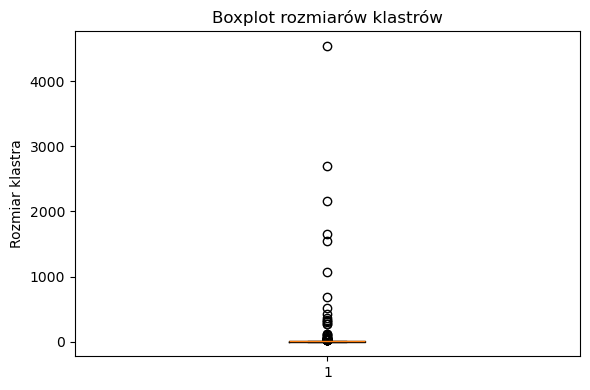


Podział klastrów:
  Train: 184 klastrów
  Val:   40 klastrów
  Test:  40 klastrów

Liczba przykładów w zbiorach:
  Train: 14913
  Val:   2349
  Test:  1738

Sumaryczne rozmiary klastrów w zbiorach:
  Train: łącznie 14913 sekwencji w 184 klastrach
  Val:   łącznie 2349 sekwencji w 40 klastrach
  Test:  łącznie 1738 sekwencji w 40 klastrach

Gotowe! Zbiory zostały podzielone z zachowaniem integralności klastrów.


In [2]:

# 1. Wybór podzbioru danych
SUBSET_SIZE = 19000  # możesz zmienić na mniejszy (np. 5000) dla szybszego testu
subset = dataset2D.select(range(min(SUBSET_SIZE, len(dataset2D))))
print(f"Liczba sekwencji w podzbiorze: {len(subset)}")

# 2. Zapis do pliku FASTA
fasta_file = "bprna_sequences.fasta"
with open(fasta_file, "w") as f:
    for i, ex in enumerate(subset):
        f.write(f">seq_{i}\n{ex['sequence']}\n")
print(f"Zapisano sekwencje do {fasta_file}")

# 3. Uruchomienie CD-HIT (próg 80% podobieństwa)
!cd-hit -i {fasta_file} -o clusters -c 0.8 -n 5 -d 0 -M 0 -T 0 > /dev/null 2>&1
print("Klastrowanie zakończone.")

# 4. Parsowanie pliku .clstr (niezawodne regexem)
def parse_clusters(clstr_file):
    clusters = []
    current = []
    with open(clstr_file, "r") as f:
        for line in f:
            line = line.strip()
            if line.startswith(">Cluster"):
                if current:
                    clusters.append(current)
                current = []
            else:
                # Wyłapuje >seq_<liczba> nawet jeśli po niej są kropki/gwiazdki
                match = re.search(r'>seq_(\d+)', line)
                if match:
                    seq_id = f"seq_{match.group(1)}"
                    current.append(seq_id)
        if current:
            clusters.append(current)
    return clusters

clusters = parse_clusters("clusters.clstr")
print(f"Liczba utworzonych klastrów: {len(clusters)}")

# 5. Walidacja zgodności liczby sekwencji
total_in_clusters = sum(len(c) for c in clusters)
print(f"Łączna liczba sekwencji w klastrach: {total_in_clusters}")
if total_in_clusters != len(subset):
    print(f"Niezgodność! W klastrach jest {total_in_clusters} sekwencji, a subset ma {len(subset)}.")

# 6. Mapowanie seq_id -> klaster
seq_to_cluster = {}
for cid, seq_list in enumerate(clusters):
    for sid in seq_list:
        seq_to_cluster[sid] = cid

# Sprawdzenie, czy wszystkie indeksy są obecne
missing = [i for i in range(len(subset)) if f"seq_{i}" not in seq_to_cluster]
if missing:
    print(f"Brakuje {len(missing)} sekwencji w mapowaniu, np. {missing[:10]}")
    # Można by je pominąć, ale lepiej wrócić do poprawy parsowania.
    # Na wszelki wypadek usuwamy je z subsetu (ale to ostateczność).
    print("UWAGA: Brakujące sekwencje zostaną pominięte w dalszych krokach.")
    valid_indices = [i for i in range(len(subset)) if f"seq_{i}" in seq_to_cluster]
    subset = subset.select(valid_indices)
    print(f"Nowy rozmiar subsetu (po usunięciu brakujących): {len(subset)}")
else:
    print("Wszystkie sekwencje poprawnie zmapowane.")

# 7. Statystyki klastrów
sizes = [len(c) for c in clusters]
print(f"\n--- Statystyki klastrów ---")
print(f"Min: {min(sizes)}, Max: {max(sizes)}, Średnia: {np.mean(sizes):.1f}, Mediana: {np.median(sizes)}")
print("Rozkład rozmiarów (pierwsze 20):")
for i, size in enumerate(sizes[:20]):
    print(f"  Klaster {i}: {size} sekwencji")

# Boxplot rozmiarów klastrów
plt.figure(figsize=(6, 4))
plt.boxplot(sizes)
plt.ylabel("Rozmiar klastra")
plt.title("Boxplot rozmiarów klastrów")
plt.tight_layout()
plt.show()

# 8. Podział klastrów na zbiory (70% train, 15% val, 15% test)
unique_clusters = list(range(len(clusters)))
random.Random(SEED).shuffle(unique_clusters)

n = len(unique_clusters)
train_clusters = set(unique_clusters[:int(0.7*n)])
val_clusters   = set(unique_clusters[int(0.7*n):int(0.85*n)])
test_clusters  = set(unique_clusters[int(0.85*n):])

print(f"\nPodział klastrów:")
print(f"  Train: {len(train_clusters)} klastrów")
print(f"  Val:   {len(val_clusters)} klastrów")
print(f"  Test:  {len(test_clusters)} klastrów")

# 9. Tworzenie list indeksów według przynależności klastrów
train_idx, val_idx, test_idx = [], [], []
for idx in range(len(subset)):
    cid = seq_to_cluster[f"seq_{idx}"]
    if cid in train_clusters:
        train_idx.append(idx)
    elif cid in val_clusters:
        val_idx.append(idx)
    else:
        test_idx.append(idx)

print(f"\nLiczba przykładów w zbiorach:")
print(f"  Train: {len(train_idx)}")
print(f"  Val:   {len(val_idx)}")
print(f"  Test:  {len(test_idx)}")

# 10. Podsumowanie rozmiarów klastrów w zbiorach
train_sizes = [sizes[c] for c in train_clusters]
val_sizes   = [sizes[c] for c in val_clusters]
test_sizes  = [sizes[c] for c in test_clusters]

print(f"\nSumaryczne rozmiary klastrów w zbiorach:")
print(f"  Train: łącznie {sum(train_sizes)} sekwencji w {len(train_clusters)} klastrach")
print(f"  Val:   łącznie {sum(val_sizes)} sekwencji w {len(val_clusters)} klastrach")
print(f"  Test:  łącznie {sum(test_sizes)} sekwencji w {len(test_clusters)} klastrach")

# 11. Utworzenie finalnych subsetów Dataset
train_dataset = subset.select(train_idx)
val_dataset   = subset.select(val_idx)
test_dataset  = subset.select(test_idx)
7

print("\nGotowe! Zbiory zostały podzielone z zachowaniem integralności klastrów.")

### Zadanie 1 (stem)
Przygotuj zbiór etykiet, w którym dla każdej pary pozycji (i, j) oznaczysz, czy należy ona do stemu. Zadanie polega na nauczeniu modelu 2D przewidywania maski stemów na podstawie macierzy kontaktów RNA.

Wskazówka:
Motyw stem zdefiniowany jest jako dwie listy nukleotydów {i, i + 1, ..., i + n} oraz {j − n, j − n + 1, ..., j}, takie że istnieją pary (i, j − n), (i + 1, j − n + 1), …, (i + n, j). Potraktuj to jako zadanie segmentacji binarnej na mapie 2D. Do uczenia użyj BCEWithLogitsLoss, a jako architekturę możesz zastosować prosty encoder-decoder z warstwami Conv2d i ConvTranspose2d.

#### Przygotowanie środowiska

In [3]:
import os

def DotBracketToBp(db: str):
    bp = []

    openingBrackets = ["(", "{", "[", "<", "A", "B"]
    closingBrackets = [")", "}", "]", ">", "a", "b"]
    stacks = [ [] for _ in openingBrackets ]

    for i in range(len(db)):
        if db[i] in openingBrackets:
            stackIdx = openingBrackets.index(db[i])
            stacks[stackIdx].append(i)
        elif db[i] in closingBrackets:
            stackIdx = closingBrackets.index(db[i])
            j = stacks[stackIdx].pop()
            bp.append((j+1, i+1))

    return bp

def DotBracketToBPSEQ(db: str, rna_seq: str):
    bp = DotBracketToBp(db)
    bp.extend([ (pair[1], pair[0]) for pair in bp])
    bp = sorted(bp,key=lambda x: x[0])
    if bp == [] :
        res = [ (idx+1, nuc, 0) for idx, nuc in enumerate(rna_seq) ]
    else:
        res = []
        bpIdx = 0
        for idx, nuc in enumerate(rna_seq):
            currentBpTuple = bp[bpIdx]
            if idx+1 == currentBpTuple[0] :
                res.append((currentBpTuple[0], nuc, currentBpTuple[1]))
                if bpIdx != len(bp)-1:
                    bpIdx += 1
            else :
                res.append((idx+1,nuc,0))
    return res

def findStems(bpseq):
    shift = 0
    startIdx = None
    startBond = None
    nucValues = np.array([ values[1] for values in bpseq])
    stems=[]
    for idx, nuc, bond in bpseq:
        if startIdx is None and startBond is None and bond > idx:
            startIdx = idx
            startBond = bond
            continue
        if startIdx is not None and startBond is not None and idx != bpseq[startBond-2-shift][2]:
            stems.append((
                (startIdx, "".join(nucValues[startIdx-1:startIdx+shift]),startIdx+shift),
                (startBond, "".join(nucValues[startBond-shift-1:startBond][::-1]),startBond-shift)
            ))
            startIdx = idx if bond > idx else None
            startBond = bond if bond > idx else None
            shift = 0
            continue
        if startIdx is not None and startBond is not None and idx == bpseq[startBond-2-shift][2]:
            shift += 1
            continue

    return stems

def dbn_to_stem_matrix(dot_bracket, rna_seq):
    L = len(dot_bracket)
    matrix = torch.zeros((L, L))
    stack = []
    bpseq = DotBracketToBPSEQ(dot_bracket, rna_seq)
    stems = findStems(bpseq)
    for start_seq, end_seq in stems:
        start_seq_range = range(start_seq[0]-1, start_seq[2])
        end_seq_range = range(end_seq[2]-1, end_seq[0])
        for i,j in zip(start_seq_range, end_seq_range):
            matrix[i,j] = 1
            matrix[j,i] = 1
    return matrix



from Bio.Seq import Seq

def rna_to_one_hot(sequence_str):
    seq = Seq(sequence_str.upper().replace("T", "U"))
    mapping = {'A': 0, 'C': 1, 'G': 2, 'U': 3}
    one_hot = torch.zeros(len(seq), 4)
    for i, base in enumerate(seq):
        if base in mapping:
            one_hot[i, mapping[base]] = 1.0
    return one_hot

dbn_to_stem_matrix(sample2D['secondary_structure'], sample2D['sequence'])

def dbn_to_matrix(dot_bracket):
    L = len(dot_bracket)
    matrix = torch.zeros((L, L))
    stack = []
    for i, char in enumerate(dot_bracket):
        if char == '(':
            stack.append(i)
        elif char == ')':
            if stack:
                j = stack.pop()
                matrix[i, j] = 1.0
                matrix[j, i] = 1.0
    return matrix


In [6]:
class RNAStemPaddedDataset(Dataset):
    def __init__(self, hf_dataset, max_len=120):
        self.data = list(hf_dataset.take(100))
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq_raw = self.data[idx]['sequence'][:self.max_len]
        dbn_raw = self.data[idx]['secondary_structure'][:self.max_len]
        curr_l = len(seq_raw)

        # 1. Generowanie reprezentacji bazowych
        x = dbn_to_matrix(dbn_raw)
        y = dbn_to_stem_matrix(dbn_raw, seq_raw)

        # 2. PADDING
        x_padded = torch.zeros((self.max_len, self.max_len))
        x_padded[:curr_l, :] = x

        y_padded = torch.zeros((self.max_len, self.max_len))
        y_padded[:curr_l, :curr_l] = y

        # 3. MASKA 1D
        mask_1d = torch.zeros(self.max_len)
        mask_1d[:curr_l] = 1.0

        # 4. MASKA 2D
        mask_2d = mask_1d.unsqueeze(0) * mask_1d.unsqueeze(1)  # (L, L)

        return x_padded, y_padded, mask_2d

stem_padded_ds = RNAStemPaddedDataset(dataset2D)
sample_x, sample_y, sample_mask = stem_padded_ds[0]

print(f"Kształt X po paddingu: {sample_x.shape}")
print(f"Kształt Y po paddingu: {sample_y.shape}")
print(f"Suma maski (faktyczna długość RNA): {sample_mask.sum().item()}")

Kształt X po paddingu: torch.Size([120, 120])
Kształt Y po paddingu: torch.Size([120, 120])
Suma maski (faktyczna długość RNA): 14400.0


In [9]:
# Najpierw musimy utworzyć DataLoader z użyciem RNAPaddedDataset.
# W sekcji 3 zdefiniowaliśmy klasę RNAPaddedDataset, która zamienia surowe dane na tensory (one-hot, macierz kontaktów, maska).
# Tutaj wykorzystamy nasze zbiory z sekcji 4 (train_dataset, val_dataset, test_dataset) – to są obiekty Dataset Hugging Face.
# Ale RNAPaddedDataset przyjmuje obiekt Hugging Face Dataset i zamienia go na tensory.
# Dlatego tworzymy instancje RNAPaddedDataset dla każdego zbioru.

from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

# Parametry
MAX_LEN = 120
BATCH_SIZE = 4

# Tworzymy przetworzone dataset'y
train_processed = RNAStemPaddedDataset(train_dataset, max_len=MAX_LEN)
val_processed = RNAStemPaddedDataset(val_dataset, max_len=MAX_LEN)
test_processed = RNAStemPaddedDataset(test_dataset, max_len=MAX_LEN)

# Tworzymy loadery
train_loader = DataLoader(train_processed, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_processed, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)


class PairwiseCNN(nn.Module):
    """
    2D CNN, który na podstawie one-hot sekwencji RNA przewiduje macierz kontaktów.
    Wejście: (B, L, 4) – kodowanie one-hot
    Wyjście: (B, L, L) – logity (przed sigmoid)
    """
    def __init__(self, hidden_channels=32, kernel_size=21):
        super().__init__()
        # Warstwy splotowe 2D – na wejściu 16 cech (4x4 z iloczynu zewnętrznego)
        self.conv1 = nn.Conv2d(1, hidden_channels, kernel_size, padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm2d(hidden_channels)
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size, padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm2d(hidden_channels)
        self.final_conv = nn.Conv2d(hidden_channels, 1, kernel_size=1)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (B, L, 4)
        # Obliczamy cechy par (i,j) jako iloczyn zewnętrzny wektorów one-hot
        x = x.unsqueeze(1)

        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        logits = self.final_conv(out).squeeze(1)      # (B, L, L)

        # Wymuszenie symetrii macierzy kontaktów
        logits = (logits + logits.transpose(1, 2)) / 2

        return logits

### DO SEKCJI 6

def weighted_bce_loss(logits, targets, mask=None, pos_weight=None):
    """
    Oblicza ważoną stratę Binary Cross Entropy dla macierzy kontaktów.

    Argumenty:
        logits (torch.Tensor): (B, L, L) – surowe wyniki modelu (przed sigmoid)
        targets (torch.Tensor): (B, L, L) – rzeczywiste etykiety (0 lub 1)
        mask (torch.Tensor, opcjonalnie): (B, L) – maska sekwencji (1 dla rzeczywistych pozycji)
        pos_weight (float, opcjonalnie): waga dla klasy pozytywnej.
                                         Jeśli None, liczona automatycznie z bieżącego batcha.

    Zwraca:
        scalar – średnia strata po uwzględnieniu maski.
    """
    if mask is None:
        mm = torch.ones_like(targets)
    else:
        mm = mask

    diag_mask = 1 - torch.eye(mask.size(-1), device=mask.device).unsqueeze(0)
    mm = mm * diag_mask

    tri_mask = torch.triu(torch.ones_like(mask), diagonal=0)
    mm = mm * tri_mask

    # Compute pos_weight dynamically if needed
    if pos_weight is None:
        pos = (targets * mm).sum().item()
        neg = ((1 - targets) * mm).sum().item()
        pos_weight = max(neg / (pos + 1e-8), 1.0)

    pos_weight_tensor = torch.as_tensor(
        pos_weight, device=logits.device, dtype=logits.dtype
    )

    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight_tensor,
        reduction='none'
    )

    loss_map = loss_fn(logits, targets)  # (B, L, L)

    # Apply mask
    loss_map = loss_map * mm

    return loss_map.sum() / (mm.sum() + 1e-8)


def compute_pos_weight(loader, device):
    """
    Liczy globalny pos_weight na podstawie całego zbioru treningowego.
    """
    total_pos = 0.0
    total_neg = 0.0

    for x_batch, y_batch, mask_batch in loader:
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)  # already (B, L, L)

        total_pos += (y_batch * mask_batch).sum().item()
        total_neg += ((1 - y_batch) * mask_batch).sum().item()

    return max(total_neg / (total_pos + 1e-8), 1.0)

# Liczymy globalne pos_weight
pos_weight = np.sqrt(compute_pos_weight(train_loader, device))
print(f"Globalne pos_weight: {pos_weight:.2f}")

# Inicjalizacja modelu, optymalizatora i schedulera
cnn_model = PairwiseCNN(hidden_channels=32).to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

def eval_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    print(f"[{name}] accuracy={acc:.3f} f1={f1:.3f} precision={prec:.3f} recall={rec:.3f}")

# Trening przez kilka epok (demonstracja)
num_epochs = 30
train_losses, val_losses = [], []

for epoch in range(1, num_epochs + 1):
    cnn_model.train()
    total_loss = 0.0

    for x_batch, y_batch, mask_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        optimizer.zero_grad()
        logits = cnn_model(x_batch)

        # Używamy globalnie policzonej wagi
        loss = weighted_bce_loss(logits, y_batch, mask_batch, pos_weight=pos_weight)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Walidacja
    cnn_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch, mask_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)

            logits = cnn_model(x_batch)
            loss = weighted_bce_loss(logits, y_batch, mask_batch, pos_weight=pos_weight)
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    print(f"Epoka {epoch:2d} | Strata treningowa: {avg_train_loss:.4f} | Strata walidacyjna: {avg_val_loss:.4f}")

print("Trening zakończony.")

Globalne pos_weight: 20.64
Epoka  1 | Strata treningowa: 0.5620 | Strata walidacyjna: 0.5000
Epoka  2 | Strata treningowa: 0.4062 | Strata walidacyjna: 0.3723
Epoka  3 | Strata treningowa: 0.2949 | Strata walidacyjna: 0.2929
Epoka  4 | Strata treningowa: 0.2191 | Strata walidacyjna: 0.2333
Epoka  5 | Strata treningowa: 0.1669 | Strata walidacyjna: 0.2080
Epoka  6 | Strata treningowa: 0.1287 | Strata walidacyjna: 0.1625
Epoka  7 | Strata treningowa: 0.1020 | Strata walidacyjna: 0.1608
Epoka  8 | Strata treningowa: 0.0812 | Strata walidacyjna: 0.1273
Epoka  9 | Strata treningowa: 0.0658 | Strata walidacyjna: 0.1246
Epoka 10 | Strata treningowa: 0.0548 | Strata walidacyjna: 0.1407
Epoka 11 | Strata treningowa: 0.0466 | Strata walidacyjna: 0.1067
Epoka 12 | Strata treningowa: 0.0389 | Strata walidacyjna: 0.1212
Epoka 13 | Strata treningowa: 0.0328 | Strata walidacyjna: 0.1235
Epoka 14 | Strata treningowa: 0.0284 | Strata walidacyjna: 0.1070
Epoka 15 | Strata treningowa: 0.0257 | Strata wal

In [10]:
print("\n--- Ocena modelu na zbiorze testowym ---")

cnn_model.eval() # Ustawiamy model w tryb ewaluacji
all_true_labels = []
all_predicted_labels = []

with torch.no_grad():
    for x_batch, y_batch, mask_batch in test_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)

        logits = cnn_model(x_batch)
        probs = torch.sigmoid(logits)
        # Przekształcamy prawdopodobieństwa na binarne przewidywania (0 lub 1)
        predictions = (probs > 0.5).long()

        # Tworzymy maskę 2D dla par (i, j)
        mm = mask_batch.unsqueeze(2) * mask_batch.unsqueeze(1) # (B, L, L)

        # Wybieramy tylko prawdziwe i przewidziane etykiety z niemaskowanych pozycji
        # Flattening allows for direct use with sklearn metrics
        valid_true = y_batch[mm.bool()].cpu().numpy()
        valid_pred = predictions[mm.bool()].cpu().numpy()

        all_true_labels.extend(valid_true)
        all_predicted_labels.extend(valid_pred)

# Konwertujemy listy na tablice numpy
all_true_labels = np.array(all_true_labels)
all_predicted_labels = np.array(all_predicted_labels)

# Wywołujemy funkcję eval_model
eval_model("Test Set", all_true_labels, all_predicted_labels)
print("Ocena zakończona.")


--- Ocena modelu na zbiorze testowym ---


IndexError: too many indices for tensor of dimension 3

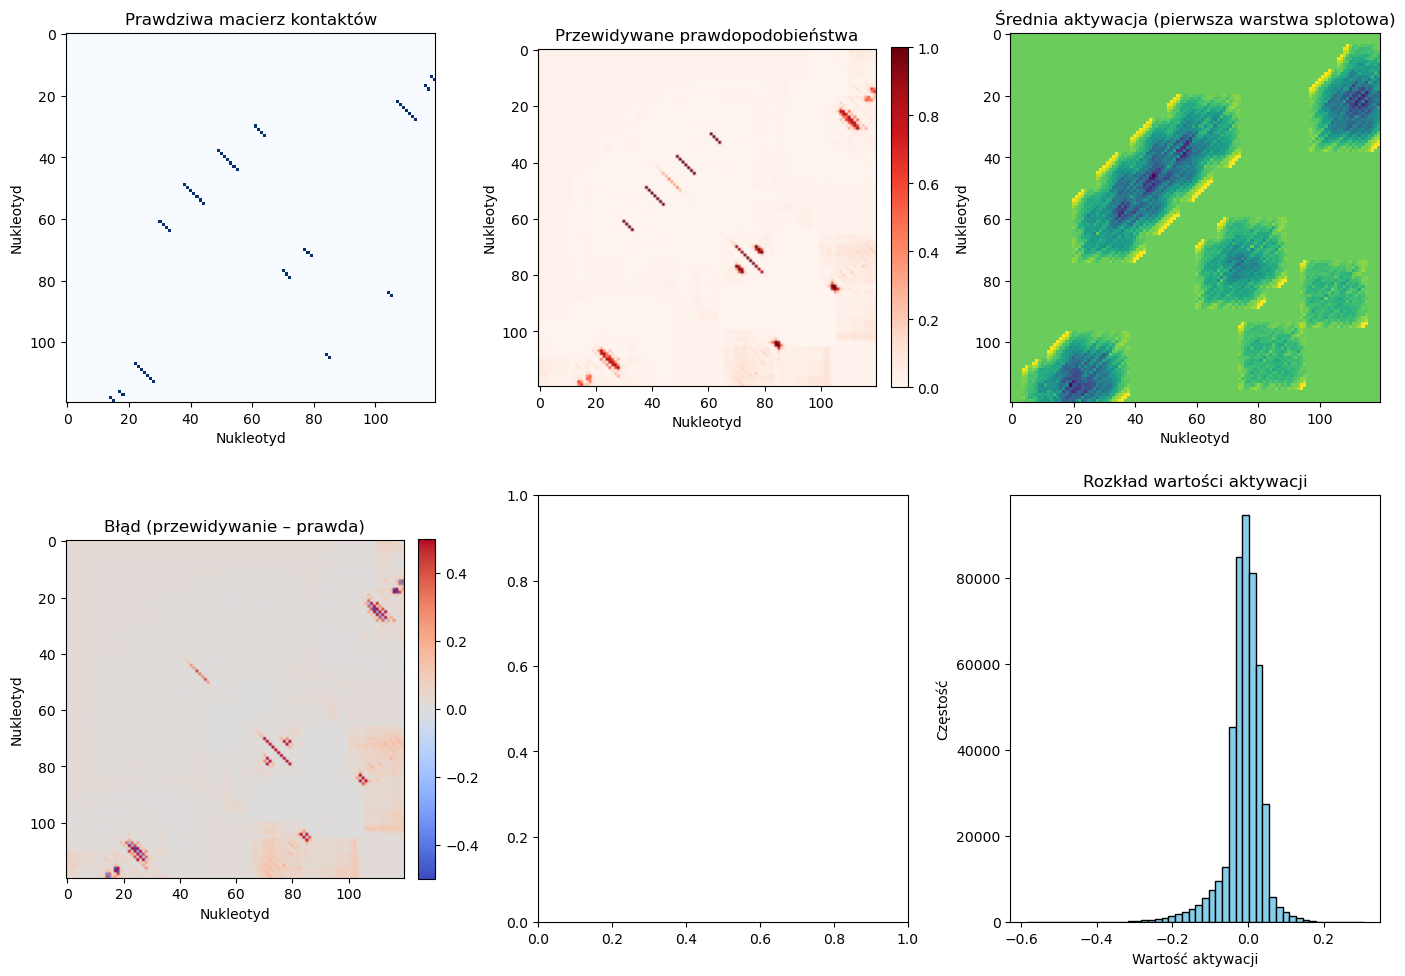

Mapy aktywacji pokazują, które obszary macierzy kontaktów są najbardziej istotne dla modelu.


In [11]:
# ========== Interpretowalność modelu ==========
import matplotlib.pyplot as plt
import numpy as np

# Pobieramy jedną próbkę z testu
x_sample, y_sample, mask_sample = next(iter(test_loader))
x_sample = x_sample[0:1].to(device)   # (1, L, 4)
y_sample = y_sample[0]                # (L, L)
mask_sample = mask_sample[0]          # (L,)
L_actual = int(mask_sample.sum().item())

# Hook do przechwycenia aktywacji pierwszej warstwy splotowej
activations = []
def hook_fn(module, input, output):
    activations.append(output.detach())

hook = cnn_model.conv1.register_forward_hook(hook_fn)

# Forward pass
cnn_model.eval()
with torch.no_grad():
    logits = cnn_model(x_sample)
    probs = torch.sigmoid(logits)

hook.remove()
act = activations[0][0]  # (hidden_channels, L, L)

# Przycinamy do rzeczywistej długości
true_contact = y_sample[:L_actual, :L_actual].cpu().numpy()
pred_prob = probs[0, :L_actual, :L_actual].cpu().numpy()
mean_act = act.mean(dim=0)[:L_actual, :L_actual].cpu().numpy()
error = pred_prob - true_contact

# Wybieramy kanał o największej wariancji aktywacji
variances = act.view(act.size(0), -1).var(dim=1)
max_var_idx = variances.argmax().item()
max_var_act = act[max_var_idx, :L_actual, :L_actual].cpu().numpy()

# Rysujemy wizualizacje
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# Macierz kontaktów prawdziwa
axes[0,0].imshow(true_contact, cmap='Blues', interpolation='nearest')
axes[0,0].set_title('Prawdziwa macierz kontaktów')
axes[0,0].set_xlabel('Nukleotyd')
axes[0,0].set_ylabel('Nukleotyd')

# Przewidywane prawdopodobieństwa
im = axes[0,1].imshow(pred_prob, cmap='Reds', vmin=0, vmax=1)
axes[0,1].set_title('Przewidywane prawdopodobieństwa')
axes[0,1].set_xlabel('Nukleotyd')
axes[0,1].set_ylabel('Nukleotyd')
plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.04)

# Średnia aktywacja z pierwszej warstwy splotowej
axes[0,2].imshow(mean_act, cmap='viridis')
axes[0,2].set_title('Średnia aktywacja (pierwsza warstwa splotowa)')
axes[0,2].set_xlabel('Nukleotyd')
axes[0,2].set_ylabel('Nukleotyd')

# Mapa błędu (różnica predykcja – prawda)
im = axes[1,0].imshow(error, cmap='coolwarm', vmin=-0.5, vmax=0.5)
axes[1,0].set_title('Błąd (przewidywanie – prawda)')
axes[1,0].set_xlabel('Nukleotyd')
axes[1,0].set_ylabel('Nukleotyd')
plt.colorbar(im, ax=axes[1,0], fraction=0.046, pad=0.04)

# Histogram aktywacji
axes[1,2].hist(act.reshape(-1).cpu().numpy(), bins=50, color='skyblue', edgecolor='black')
axes[1,2].set_title('Rozkład wartości aktywacji')
axes[1,2].set_xlabel('Wartość aktywacji')
axes[1,2].set_ylabel('Częstość')

plt.tight_layout()
plt.show()

print("Mapy aktywacji pokazują, które obszary macierzy kontaktów są najbardziej istotne dla modelu.")

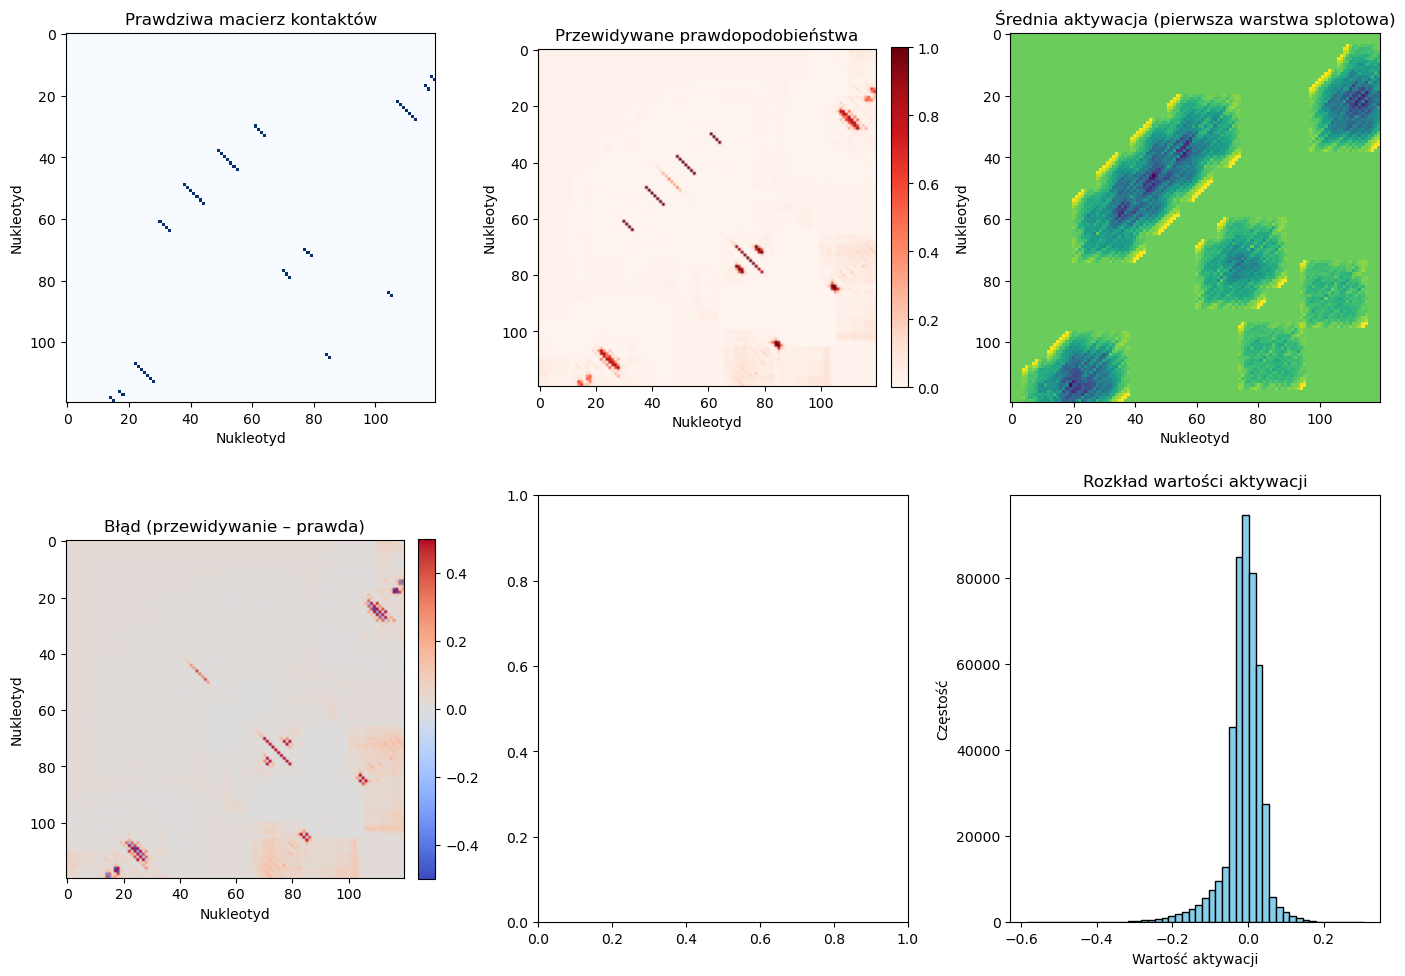

Mapy aktywacji pokazują, które obszary macierzy kontaktów są najbardziej istotne dla modelu.


In [11]:
# ========== Interpretowalność modelu ==========
import matplotlib.pyplot as plt
import numpy as np

# Pobieramy jedną próbkę z testu
x_sample, y_sample, mask_sample = next(iter(test_loader))
x_sample = x_sample[0:1].to(device)   # (1, L, 4)
y_sample = y_sample[0]                # (L, L)
mask_sample = mask_sample[0]          # (L,)
L_actual = int(mask_sample.sum().item())

# Hook do przechwycenia aktywacji pierwszej warstwy splotowej
activations = []
def hook_fn(module, input, output):
    activations.append(output.detach())

hook = cnn_model.conv1.register_forward_hook(hook_fn)

# Forward pass
cnn_model.eval()
with torch.no_grad():
    logits = cnn_model(x_sample)
    probs = torch.sigmoid(logits)

hook.remove()
act = activations[0][0]  # (hidden_channels, L, L)

# Przycinamy do rzeczywistej długości
true_contact = y_sample[:L_actual, :L_actual].cpu().numpy()
pred_prob = probs[0, :L_actual, :L_actual].cpu().numpy()
mean_act = act.mean(dim=0)[:L_actual, :L_actual].cpu().numpy()
error = pred_prob - true_contact

# Wybieramy kanał o największej wariancji aktywacji
variances = act.view(act.size(0), -1).var(dim=1)
max_var_idx = variances.argmax().item()
max_var_act = act[max_var_idx, :L_actual, :L_actual].cpu().numpy()

# Rysujemy wizualizacje
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

# Macierz kontaktów prawdziwa
axes[0,0].imshow(true_contact, cmap='Blues', interpolation='nearest')
axes[0,0].set_title('Prawdziwa macierz kontaktów')
axes[0,0].set_xlabel('Nukleotyd')
axes[0,0].set_ylabel('Nukleotyd')

# Przewidywane prawdopodobieństwa
im = axes[0,1].imshow(pred_prob, cmap='Reds', vmin=0, vmax=1)
axes[0,1].set_title('Przewidywane prawdopodobieństwa')
axes[0,1].set_xlabel('Nukleotyd')
axes[0,1].set_ylabel('Nukleotyd')
plt.colorbar(im, ax=axes[0,1], fraction=0.046, pad=0.04)

# Średnia aktywacja z pierwszej warstwy splotowej
axes[0,2].imshow(mean_act, cmap='viridis')
axes[0,2].set_title('Średnia aktywacja (pierwsza warstwa splotowa)')
axes[0,2].set_xlabel('Nukleotyd')
axes[0,2].set_ylabel('Nukleotyd')

# Mapa błędu (różnica predykcja – prawda)
im = axes[1,0].imshow(error, cmap='coolwarm', vmin=-0.5, vmax=0.5)
axes[1,0].set_title('Błąd (przewidywanie – prawda)')
axes[1,0].set_xlabel('Nukleotyd')
axes[1,0].set_ylabel('Nukleotyd')
plt.colorbar(im, ax=axes[1,0], fraction=0.046, pad=0.04)

# Histogram aktywacji
axes[1,2].hist(act.reshape(-1).cpu().numpy(), bins=50, color='skyblue', edgecolor='black')
axes[1,2].set_title('Rozkład wartości aktywacji')
axes[1,2].set_xlabel('Wartość aktywacji')
axes[1,2].set_ylabel('Częstość')

plt.tight_layout()
plt.show()

print("Mapy aktywacji pokazują, które obszary macierzy kontaktów są najbardziej istotne dla modelu.")

###Zadanie 2 (hairpin + stem)

Przygotuj etykiety opisujące obecność motywów strukturalnych hairpin oraz stem. Następnie zbuduj model konwolucyjny 2D, który na podstawie macierzy kontaktów przewiduje jednocześnie obie etykiety.

Wskazówka:
Motyw hairpin zdefiniowany jest jako lista nukleotydów {i, i + 1, ..., j}, taka że istnieje para (i, j) oraz nukleotydy {i + 1, i + 2, ..., j − 1} są niesparowane.



In [26]:
def findHairpins(bpseq):
    hairpins = []
    nucValues = np.array([ values[1] for values in bpseq])
    startIdx = None;

    for idx, nuc, bond in bpseq:
        if bond == 0 :
            continue
        if bond > idx:
            startIdx = idx
            continue
        if startIdx is not None and bond != startIdx:
            startIdx = None
            continue
        if startIdx is not None and startIdx == bond:
            hairpins.append((startIdx,"".join(nucValues[startIdx-1:idx]),idx))
    return hairpins

def dbn_to_hairpin_matrix(dot_bracket, rna_seq):
    L = len(dot_bracket)
    matrix = torch.zeros((L, L))
    stack = []
    bpseq = DotBracketToBPSEQ(dot_bracket, rna_seq)
    stems = findHairpins(bpseq)
    for seq in stems:
        seq_range = range(seq[0]-1, seq[2])
        for i in zip(seq_range):
            for j in zip(seq_range):
                matrix[i,j] = 1
                matrix[j,i] = 1
    return matrix

In [35]:
class RNAStemHairpinPaddedDataset(Dataset):
    def __init__(self, hf_dataset, max_len=120):
        self.data = list(hf_dataset.take(100))
        self.max_len = max_len

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        seq_raw = self.data[idx]['sequence'][:self.max_len]
        dbn_raw = self.data[idx]['secondary_structure'][:self.max_len]

        curr_l = min(len(seq_raw), len(dbn_raw), self.max_len)

        x = dbn_to_matrix(dbn_raw)

        y_stem = dbn_to_stem_matrix(dbn_raw, seq_raw)
        y_hairpin = dbn_to_hairpin_matrix(dbn_raw, seq_raw)

        x_padded = torch.zeros((self.max_len, self.max_len), dtype=torch.float32)
        x_padded[:curr_l, :curr_l] = x[:curr_l, :curr_l]

        y_padded = torch.zeros((2, self.max_len, self.max_len), dtype=torch.float32)
        y_padded[0, :curr_l, :curr_l] = y_stem[:curr_l, :curr_l]
        y_padded[1, :curr_l, :curr_l] = y_hairpin[:curr_l, :curr_l]

        mask = torch.zeros((1, self.max_len, self.max_len), dtype=torch.float32)
        mask[:, :curr_l, :curr_l] = 1.0

        return x_padded, y_padded, mask



In [41]:
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F

# Parametry
MAX_LEN = 120
BATCH_SIZE = 4

# Tworzymy przetworzone dataset'y
train_processed = RNAStemHairpinPaddedDataset(train_dataset, max_len=MAX_LEN)
val_processed = RNAStemHairpinPaddedDataset(val_dataset, max_len=MAX_LEN)
test_processed = RNAStemHairpinPaddedDataset(test_dataset, max_len=MAX_LEN)

# Tworzymy loadery
train_loader = DataLoader(train_processed, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_processed, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_processed, batch_size=BATCH_SIZE, shuffle=False)


class PairwiseCNN(nn.Module):
    """
    Input : (B, 2, L, L)  -> contact + (optional symmetry / feature channel)
    Output: (B, 2, L, L)  -> stem + hairpin logits
    """

    def __init__(self, hidden_channels=32, kernel_size=21):
        super().__init__()

        self.conv1 = nn.Conv2d(1, hidden_channels, kernel_size,
                               padding=kernel_size // 2)
        self.bn1 = nn.BatchNorm2d(hidden_channels)

        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size,
                               padding=kernel_size // 2)
        self.bn2 = nn.BatchNorm2d(hidden_channels)

        self.conv3 = nn.Conv2d(hidden_channels, hidden_channels, 1)

        # IMPORTANT: 2 output channels (stem + hairpin)
        self.final_conv = nn.Conv2d(hidden_channels, 2, kernel_size=1)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        # x: (B, 2, L, L)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.relu(self.conv3(out))

        logits = self.final_conv(out)  # (B, 2, L, L)

        return logits

### DO SEKCJI 6
def weighted_bce_loss(logits, targets, mask=None, pos_weight=None):
    """
    logits  : (B, 2, L, L)
    targets : (B, 2, L, L)
    mask    : (B, 1, L, L)
    pos_weight : (2,)
    """

    B, C, L, _ = logits.shape

    if mask is None:
        mm = torch.ones((B, 1, L, L), device=logits.device)
    else:
        mm = mask  # (B,1,L,L)

    diag = torch.eye(L, device=logits.device).view(1, 1, L, L)
    mm = mm * (1 - diag)

    tri = torch.triu(torch.ones((L, L), device=logits.device), diagonal=1)
    tri = tri.view(1, 1, L, L)
    mm = mm * tri

    mm = mm.expand(-1, C, -1, -1)  # (B,2,L,L)

    if pos_weight is None:
        pos = (targets * mm).sum(dim=(0,2,3))   # (2,)
        neg = ((1 - targets) * mm).sum(dim=(0,2,3))
        pos_weight = torch.clamp(neg / (pos + 1e-8), min=1.0)

    pos_weight = pos_weight.to(logits.device)

    loss_fn = nn.BCEWithLogitsLoss(
        pos_weight=pos_weight,
        reduction='none'
    )

    loss_map = loss_fn(logits, targets)  # (B,2,L,L)

    # --- APPLY MASK ---
    loss_map = loss_map * mm

    return loss_map.sum() / (mm.sum() + 1e-8)

def compute_pos_weight(loader, device):
    total_pos = torch.zeros(2, device=device)
    total_neg = torch.zeros(2, device=device)

    for x_batch, y_batch, mask_batch in loader:
        y_batch = y_batch.to(device)          # (B,2,L,L)
        mask_batch = mask_batch.to(device)    # (B,1,L,L)

        pos = (y_batch * mask_batch).sum(dim=(0,2,3))   # (2,)
        neg = ((1 - y_batch) * mask_batch).sum(dim=(0,2,3))

        total_pos += pos
        total_neg += neg

    return torch.clamp(total_neg / (total_pos + 1e-8), min=1.0)



# Liczymy globalne pos_weight
pos_weight = torch.sqrt(compute_pos_weight(train_loader, device))
print(f"Globalne pos_weight: {pos_weight}")

# Inicjalizacja modelu, optymalizatora i schedulera
cnn_model = PairwiseCNN(hidden_channels=32).to(device)
optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

def eval_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    print(f"[{name}] accuracy={acc:.3f} f1={f1:.3f} precision={prec:.3f} recall={rec:.3f}")

# Trening przez kilka epok (demonstracja)
num_epochs = 30
train_losses, val_losses = [], []

for epoch in range(1, num_epochs + 1):
    cnn_model.train()
    total_loss = 0.0

    for x_batch, y_batch, mask_batch in train_loader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)
        mask_batch = mask_batch.to(device)
        x_batch = x_batch.unsqueeze(1)

        optimizer.zero_grad()
        logits = cnn_model(x_batch)

        # Używamy globalnie policzonej wagi
        loss = weighted_bce_loss(logits, y_batch, mask_batch, pos_weight=pos_weight.view(1, 2, 1, 1))

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Walidacja
    cnn_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch, mask_batch in val_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            mask_batch = mask_batch.to(device)
            x_batch = x_batch.unsqueeze(1)

            logits = cnn_model(x_batch)
            loss = weighted_bce_loss(logits, y_batch, mask_batch, pos_weight=pos_weight.view(1, 2, 1, 1))
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    scheduler.step(avg_val_loss)
    print(f"Epoka {epoch:2d} | Strata treningowa: {avg_train_loss:.4f} | Strata walidacyjna: {avg_val_loss:.4f}")

print("Trening zakończony.")

Globalne pos_weight: tensor([20.6409, 14.5880], device='cuda:0')
Epoka  1 | Strata treningowa: 0.5961 | Strata walidacyjna: 0.4167
Epoka  2 | Strata treningowa: 0.3253 | Strata walidacyjna: 0.2722
Epoka  3 | Strata treningowa: 0.1215 | Strata walidacyjna: 0.1224
Epoka  4 | Strata treningowa: 0.0431 | Strata walidacyjna: 0.0756
Epoka  5 | Strata treningowa: 0.0218 | Strata walidacyjna: 0.0817
Epoka  6 | Strata treningowa: 0.0148 | Strata walidacyjna: 0.0583
Epoka  7 | Strata treningowa: 0.0118 | Strata walidacyjna: 0.0921
Epoka  8 | Strata treningowa: 0.0092 | Strata walidacyjna: 0.0767
Epoka  9 | Strata treningowa: 0.0087 | Strata walidacyjna: 0.0620
Epoka 10 | Strata treningowa: 0.0074 | Strata walidacyjna: 0.0820
Epoka 11 | Strata treningowa: 0.0065 | Strata walidacyjna: 0.0548
Epoka 12 | Strata treningowa: 0.0066 | Strata walidacyjna: 0.0676
Epoka 13 | Strata treningowa: 0.0062 | Strata walidacyjna: 0.1049
Epoka 14 | Strata treningowa: 0.0058 | Strata walidacyjna: 0.0834
Epoka 15 | 

###Zadanie 3 (bonus)
Wyszukaj w Internecie zbiór danych związany z bioinformatyką strukturalną (np. przewidywanie oddziaływań białko-białko, klasyfikacja typów RNA, lub inny). Zaimportuj dane, wykonaj preprocessing, podziel na zbiory (pamiętając o klastrowaniu biologicznym) i zastosuj wybrany model (może być ten sam PairwiseCNN, ale dostosowany do nowego problemu). Porównaj wyniki z naszym zadaniem i przedstaw wnioski.

Opisz jaki zbiór wybrałeś, jak go wczytałeś i jakie uzyskałeś wyniki.

Accuracy STEM: 0.9876
Accuracy HAIRPIN: 0.9274


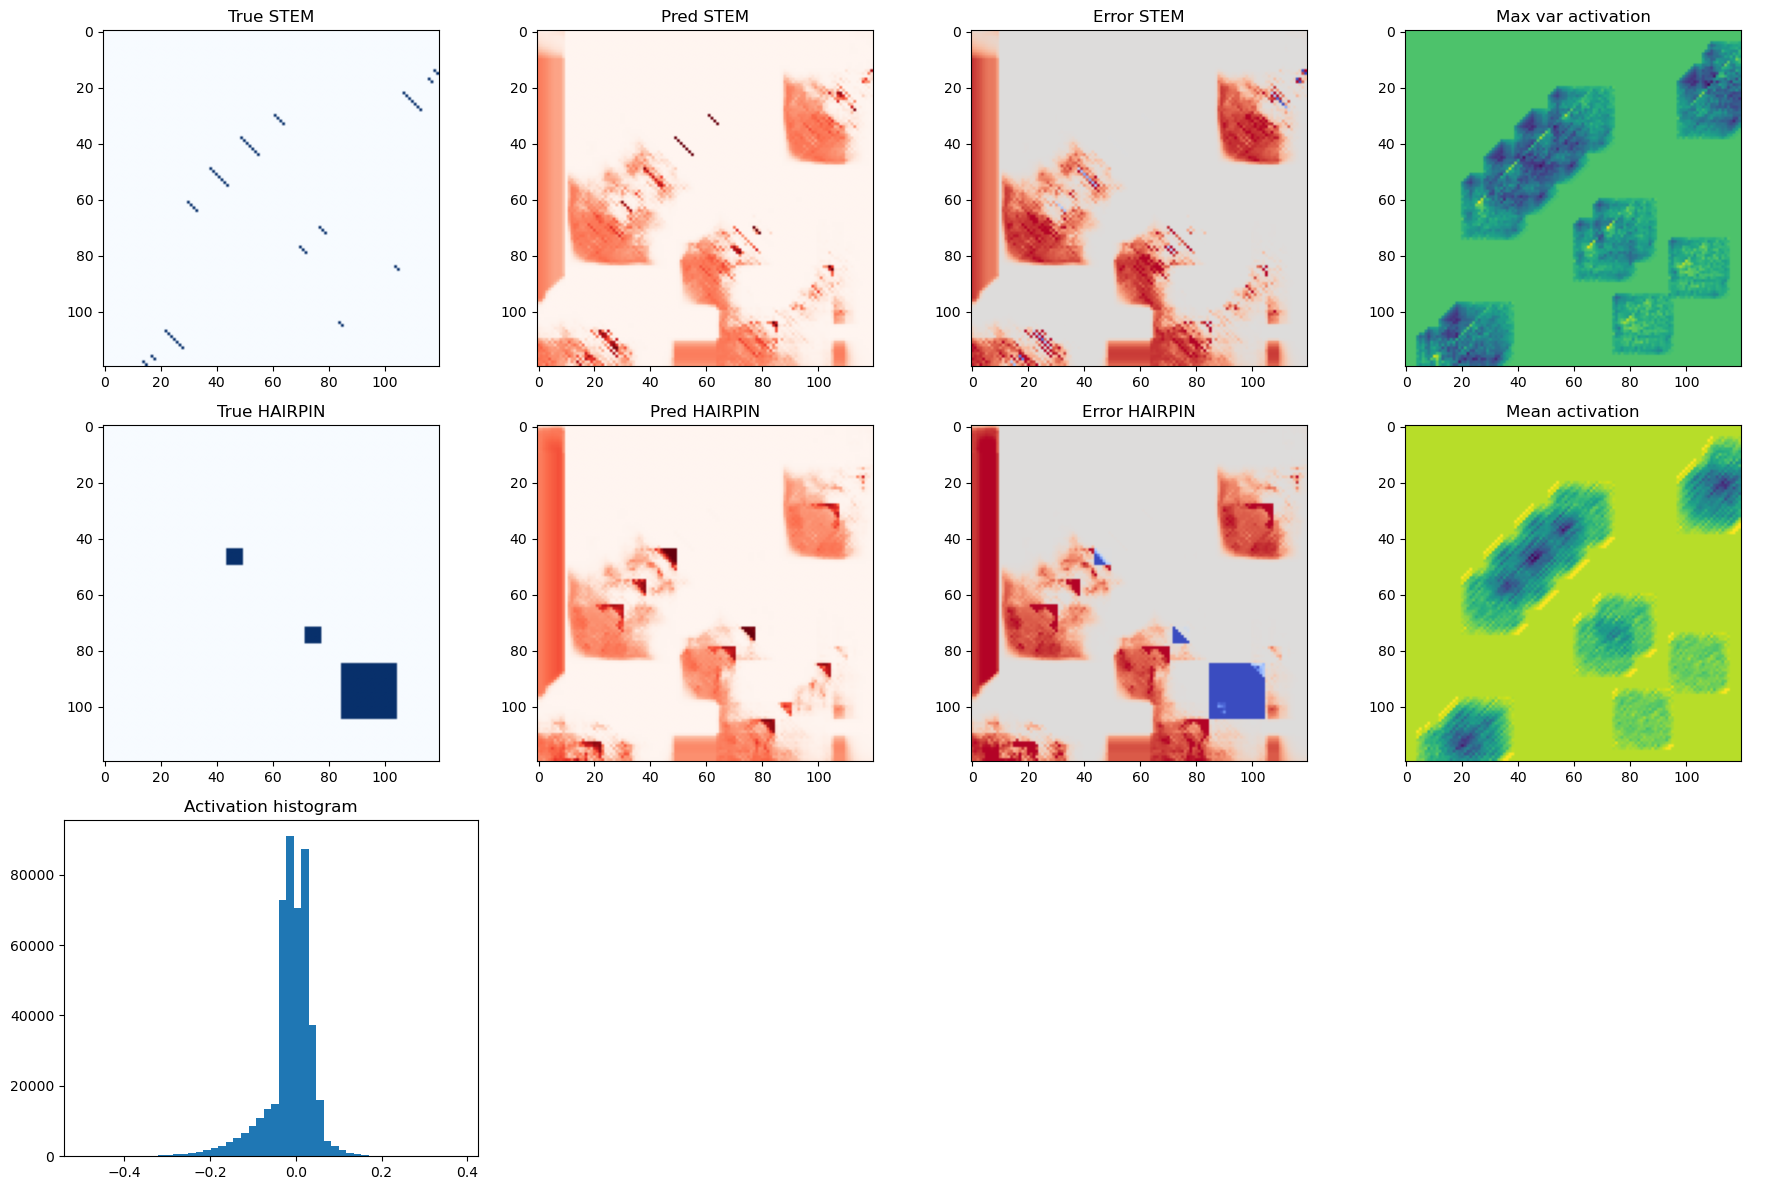

Interpretowalność gotowa: wizualizacja dla STEM i HAIRPIN oraz aktywacje CNN.


In [44]:
# ========== Interpretowalność modelu ==========
import matplotlib.pyplot as plt
import numpy as np
import torch

# ===== GET SAMPLE =====
x_sample, y_sample, mask_sample = next(iter(test_loader))

x_sample = x_sample[0:1].to(device)       # (1, L, L)
y_sample = y_sample[0:1].to(device)       # (1, 2, L, L)
mask_sample = mask_sample[0:1].to(device) # (1, 1, L, L)

# add channel dim for model
x_sample = x_sample.unsqueeze(1)          # (1, 1, L, L)

# ===== HOOK =====
activations = []
def hook_fn(module, input, output):
    activations.append(output.detach())

hook = cnn_model.conv1.register_forward_hook(hook_fn)

# ===== FORWARD =====
cnn_model.eval()
with torch.no_grad():
    logits = cnn_model(x_sample)          # (1, 2, L, L)
    probs = torch.sigmoid(logits)

hook.remove()

# ===== GET DATA =====
act = activations[0][0]  # (C, L, L)

mask_2d = mask_sample[0, 0]  # (L, L)
L_actual = int(mask_2d.sum(dim=0).max().item())

# crop
true_stem = y_sample[0, 0, :L_actual, :L_actual].cpu().numpy()
true_hairpin = y_sample[0, 1, :L_actual, :L_actual].cpu().numpy()

pred_stem = probs[0, 0, :L_actual, :L_actual].cpu().numpy()
pred_hairpin = probs[0, 1, :L_actual, :L_actual].cpu().numpy()

# binarize
pred_stem_bin = (pred_stem > 0.5).astype(np.float32)
pred_hairpin_bin = (pred_hairpin > 0.5).astype(np.float32)

# ===== ACCURACY =====
mask_np = mask_2d[:L_actual, :L_actual].cpu().numpy()

def masked_accuracy(pred, true, mask):
    correct = ((pred == true) * mask).sum()
    total = mask.sum() + 1e-8
    return correct / total

acc_stem = masked_accuracy(pred_stem_bin, true_stem, mask_np)
acc_hairpin = masked_accuracy(pred_hairpin_bin, true_hairpin, mask_np)

print(f"Accuracy STEM: {acc_stem:.4f}")
print(f"Accuracy HAIRPIN: {acc_hairpin:.4f}")

# ===== ACTIVATIONS =====
mean_act = act.mean(dim=0)[:L_actual, :L_actual].cpu().numpy()

variances = act.view(act.size(0), -1).var(dim=1)
max_var_idx = variances.argmax().item()
max_var_act = act[max_var_idx, :L_actual, :L_actual].cpu().numpy()

# ===== ERROR =====
error_stem = pred_stem - true_stem
error_hairpin = pred_hairpin - true_hairpin

# ===== PLOTS =====
fig, axes = plt.subplots(3, 4, figsize=(18, 12))

# --- STEM ---
axes[0,0].imshow(true_stem, cmap='Blues')
axes[0,0].set_title('True STEM')

axes[0,1].imshow(pred_stem, cmap='Reds', vmin=0, vmax=1)
axes[0,1].set_title('Pred STEM')

axes[0,2].imshow(error_stem, cmap='coolwarm', vmin=-0.5, vmax=0.5)
axes[0,2].set_title('Error STEM')

axes[0,3].imshow(max_var_act, cmap='viridis')
axes[0,3].set_title('Max var activation')

# --- HAIRPIN ---
axes[1,0].imshow(true_hairpin, cmap='Blues')
axes[1,0].set_title('True HAIRPIN')

axes[1,1].imshow(pred_hairpin, cmap='Reds', vmin=0, vmax=1)
axes[1,1].set_title('Pred HAIRPIN')

axes[1,2].imshow(error_hairpin, cmap='coolwarm', vmin=-0.5, vmax=0.5)
axes[1,2].set_title('Error HAIRPIN')

axes[1,3].imshow(mean_act, cmap='viridis')
axes[1,3].set_title('Mean activation')

# --- HISTOGRAM ---
axes[2,0].hist(act.reshape(-1).cpu().numpy(), bins=50)
axes[2,0].set_title('Activation histogram')

axes[2,1].axis('off')
axes[2,2].axis('off')
axes[2,3].axis('off')

plt.tight_layout()
plt.show()

print("Interpretowalność gotowa: wizualizacja dla STEM i HAIRPIN oraz aktywacje CNN.")